# Equity Analysis with Python - Introduction (Part 1)

__Please install yfinance__ with the following command (Anaconda Prompt/Terminal Window):

pip install yfinance

## yfinance API - first steps

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [3]:
yf.__version__

'1.4.1'

In [4]:
symbol = "AAPL" # ticker symbol for Apple Inc.

In [5]:
df = yf.download(tickers = symbol)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


In [6]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [7]:
df = yf.download(tickers = symbol ,period = "max", multi_level_index = False)
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093084,0.093510,0.093084,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200


In [8]:
df.index

DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-26',
               ...
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-06'],
              dtype='datetime64[ns]', name='Date', length=11481, freq=None)

In [9]:
df.index = pd.to_datetime(df.index.date)
df

,Close,High,Low,Open,Volume
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093084,0.093510,0.093084,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


In [10]:
df.index

DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-26',
               ...
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-06'],
              dtype='datetime64[ns]', length=11481, freq=None)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11481 entries, 1980-12-12 to 2026-07-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   11481 non-null  float64
 1   High    11481 non-null  float64
 2   Low     11481 non-null  float64
 3   Open    11481 non-null  float64
 4   Volume  11481 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 538.2 KB


- __Date__: Date (year-month-day) at midnight New York Time (business daily data without weekends and bank holidays)
- __Open__: daily Open Price @ 9:30 am Eastern TimeZone
- __High__: daily high/max price
- __Low__: daily low/min price
- __Close__: daily Close Price @ 4:00 pm Eastern TimeZone
- __Adj Close__: Close price adjusted for Dividend Payments (backward adjusted)
- __Volume__: daily Trading Volume (number of Shares)

__Price Chart__

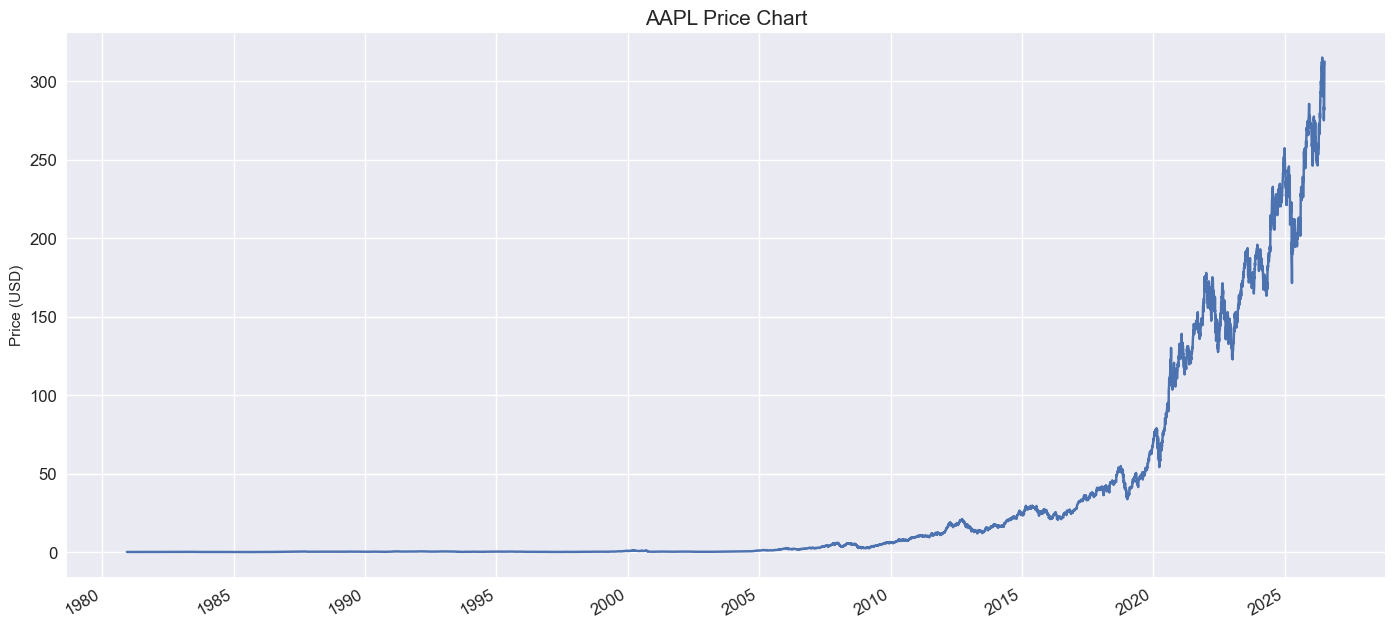

In [12]:
df.Close.plot(figsize = (17, 8), fontsize = 12)
plt.ylabel("Price (USD)")
plt.title("AAPL Price Chart", fontsize = 15)
plt.show()

In [13]:
df.index = pd.to_datetime(df.index)

In [14]:
len(df.index.year.unique())

47

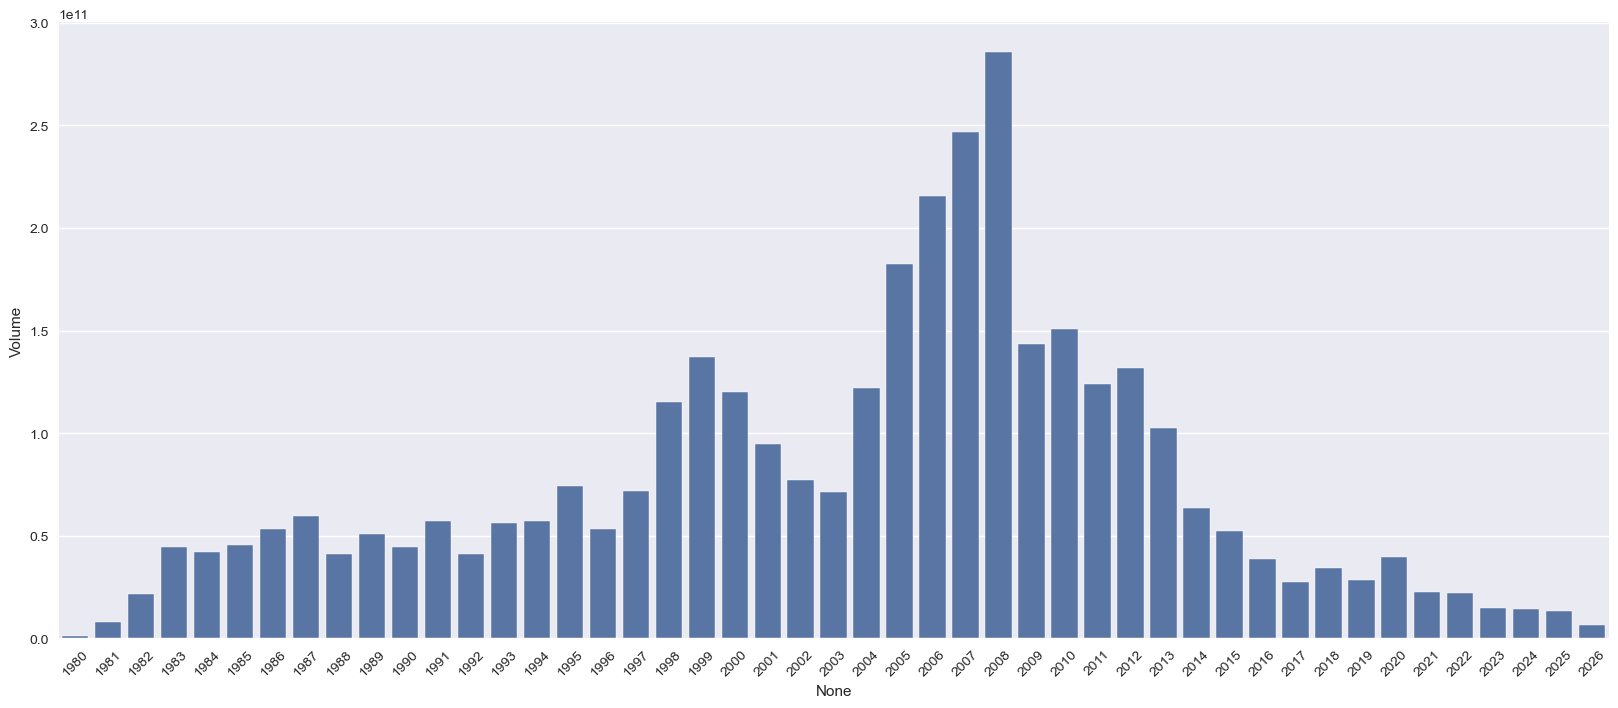

In [15]:
plt.figure(figsize = (20,8))
sns.barplot(data = df.groupby(df.index.year).agg({"Volume": "sum"}) , x =  df.index.year.unique() , y = "Volume" )
plt.xticks(rotation = 45)
plt.show()

In [16]:
df.index.year.unique()

Index([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
      dtype='int32')

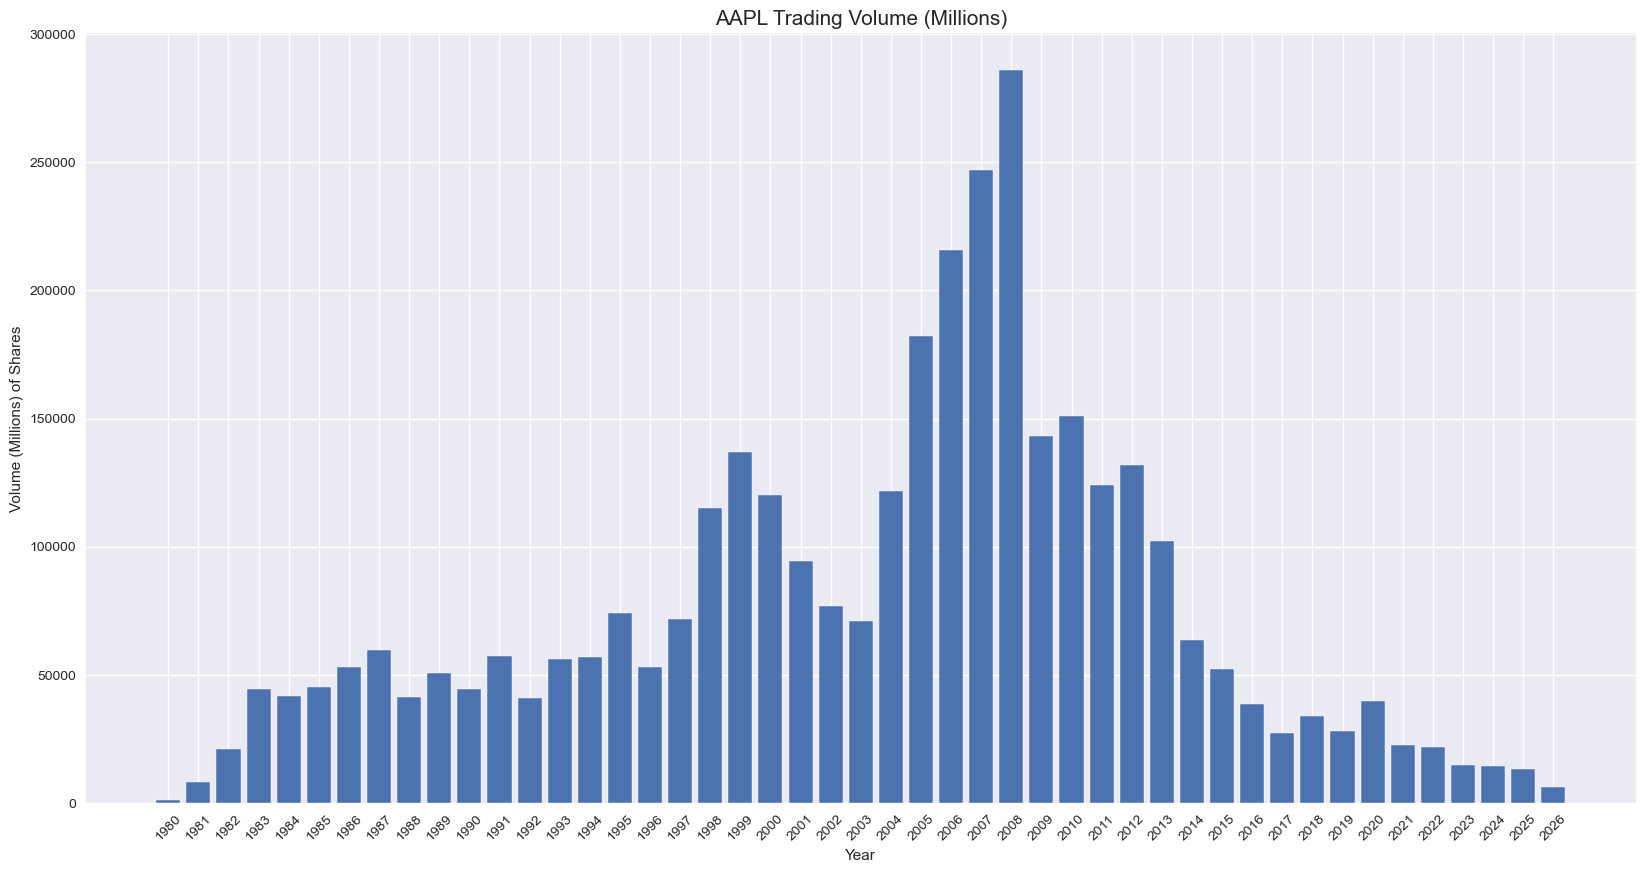

In [17]:
plt.figure(figsize = (20,10))
plt.bar(df.index.year.unique().astype(str), 
        df.groupby(df.index.year).agg({"Volume": "sum"})["Volume"].div(10**6))
plt.title("AAPL Trading Volume (Millions)", fontsize = 15)
plt.xticks(rotation = 45)
plt.ylabel("Volume (Millions) of Shares")
plt.xlabel("Year")
plt.show()

__Volume Chart__

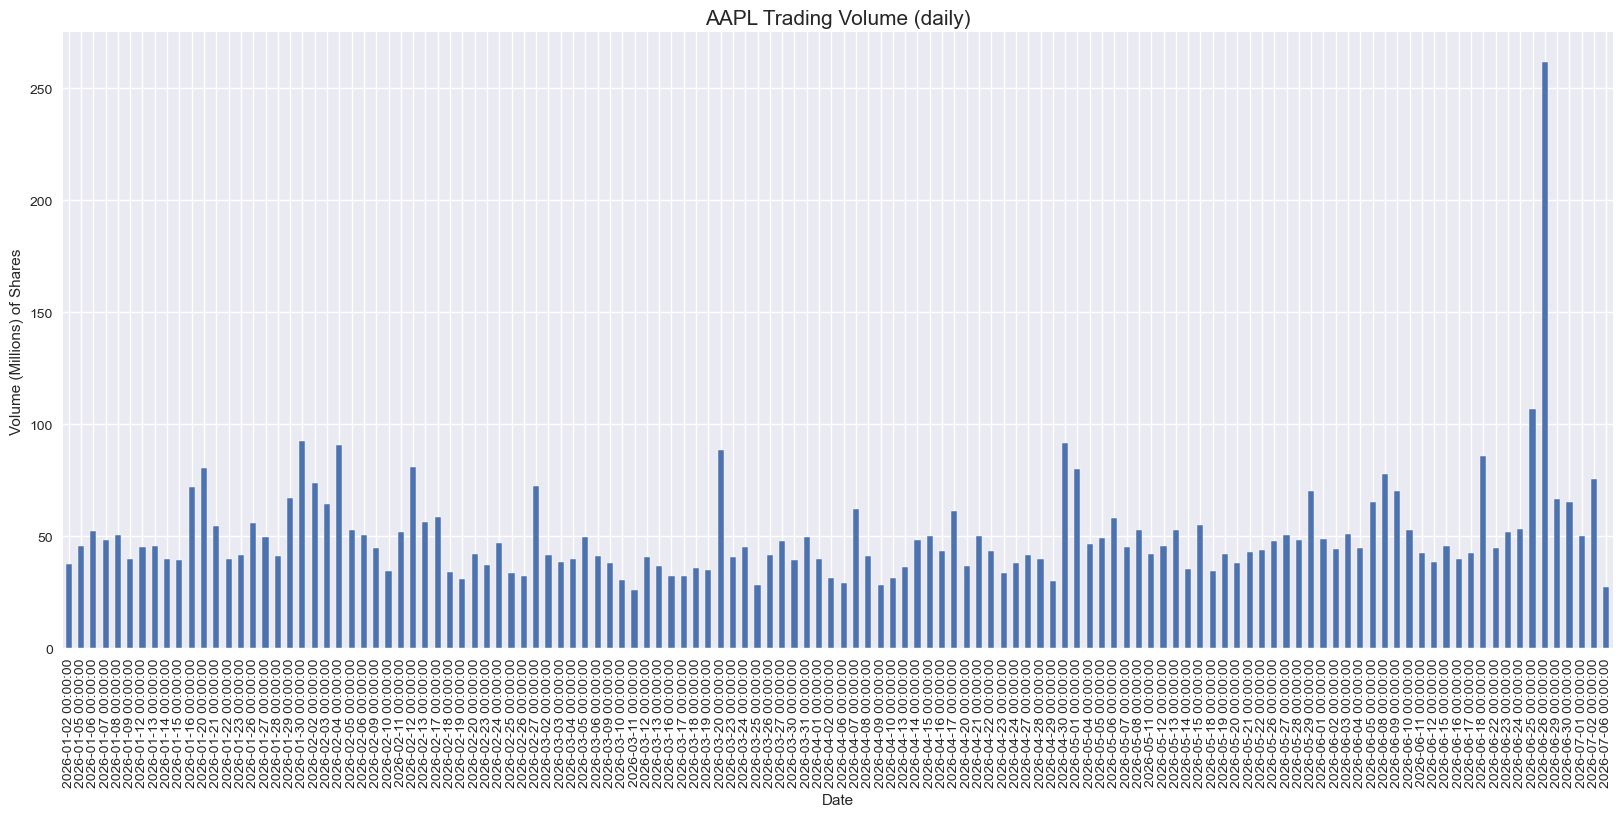

In [18]:
df.loc["2026", "Volume"].div(10**6).plot(figsize = (20,8), kind = "bar")
plt.ylabel("Volume (Millions) of Shares")
plt.xlabel("Date")
plt.title("AAPL Trading Volume (daily)", fontsize = 15)
plt.show()

$\text{Market Value} = \text{Volume} \times \text{Closing Price}$

In [19]:
df.Volume.mul(df.Close) # Trading Volume (USD Value)

1980-12-12    4.606239e+07
1980-12-15    1.637197e+07
1980-12-16    9.119182e+06
1980-12-17    7.640245e+06
1980-12-18    6.680146e+06
                  ...     
2026-06-29    1.871514e+10
2026-06-30    1.883739e+10
2026-07-01    1.476734e+10
2026-07-02    2.325614e+10
2026-07-06    8.500153e+09
Length: 11481, dtype: float64

## Excursus: Versions and Updates

Note: From yfinance version 0.2.48, loading one symbol with yf.download() will lead to a Multi Level Index.
To avoid this, set multi_level_index=False

In [20]:
yf.download(tickers = symbol) # creates a Multi Level Index (from yfinance 0.2.48)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


In [21]:
yf.download(tickers = symbol, multi_level_index=False) # avoids Multi Level Index (from yfinance 0.2.48)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200


You can get the __latest version__ of yfinance with the following command (Anaconda Prompt/Terminal Window):

pip install yfinance --upgrade

In [22]:
yf.__version__

'1.4.1'

## Analysis Period

In [23]:
df

,Close,High,Low,Open,Volume
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093084,0.093510,0.093084,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


In [24]:
df.loc["2022-01-01":"2022-01-15"]

,Close,High,Low,Open,Volume
2022-01-03,177.939728,178.790282,173.735900,173.853212,104487900
2022-01-04,175.681396,178.848946,175.114365,178.545881,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153610,171.379816,167.801660,168.837953,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100
2022-01-10,168.339371,168.642436,164.409265,165.298918,106765600
2022-01-11,171.164703,171.262458,166.999975,168.466430,76138300
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200
2022-01-13,168.339371,172.670297,167.948307,171.849085,84505800
2022-01-14,169.199646,169.893760,167.263914,167.508323,80440800


In [25]:
df.loc["2022"]

,Close,High,Low,Open,Volume
2022-01-03,177.939728,178.790282,173.735900,173.853212,104487900
2022-01-04,175.681396,178.848946,175.114365,178.545881,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153610,171.379816,167.801660,168.837953,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100
...,...,...,...,...,...
2022-12-23,129.659409,130.210060,127.476457,128.735094,63814900
2022-12-27,127.859970,129.216945,126.571835,129.187446,69007800
2022-12-28,123.936523,128.843243,123.769362,127.505940,85438400
2022-12-29,127.446976,128.302452,125.598353,125.854009,75703700


In [26]:
df.loc["2017":]

,Close,High,Low,Open,Volume
2017-01-03,26.721239,26.762650,26.401459,26.640719,115127600
2017-01-04,26.691328,26.804058,26.629213,26.652219,84472400
2017-01-05,26.827066,26.884581,26.643019,26.668326,88774400
2017-01-06,27.126139,27.183653,26.794855,26.866172,127007600
2017-01-09,27.374605,27.475831,27.133045,27.135345,134247600
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


In [27]:
df = yf.download(tickers = symbol, start = "2020-07-01", end = "2020-12-31")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-07-01,88.135353,88.922038,88.086946,88.379833,110737200
2020-07-02,88.135353,89.674839,88.021593,89.040651,114041600
2020-07-06,90.493011,90.960180,89.529622,89.561091,118655600
2020-07-07,90.212227,91.647623,90.100883,90.870622,112424400
2020-07-08,92.313263,92.344732,91.100555,91.187700,117092000
...,...,...,...,...,...
2020-12-23,127.246902,128.675210,127.071998,128.412876,88223700
2020-12-24,128.228256,129.676016,127.382928,127.596692,54930100


Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

In [28]:
df = yf.download(tickers = symbol, period = "1mo") # last 30 days
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


In [29]:
df = yf.download(tickers = symbol, period = "1y") # last 365 days 
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-07-07,209.120361,215.375544,207.974912,211.839569,50229000
2025-07-08,209.180130,210.594517,207.626297,209.269786,42848900
2025-07-09,210.305664,210.494916,206.401156,208.702025,48749400
2025-07-10,211.570663,212.636427,209.200063,209.678162,44443600
2025-07-11,210.325592,211.291760,209.030726,209.737927,39765800
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


In [30]:
df = yf.download(tickers = symbol, period = "ytd") # year-to-date 
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.507416,277.324736,268.501134,271.755098,37838100
2026-01-05,266.764374,271.006492,265.646456,270.138110,45647200
2026-01-06,261.873444,267.053821,261.633898,266.504853,52352100
2026-01-07,259.847198,263.190992,259.328174,262.711902,48309800
2026-01-08,258.559631,258.809168,255.225814,256.543358,50419300
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


In [31]:
df = yf.download(tickers = symbol, period = "max") # max
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093084,0.093510,0.093084,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


## Data Frequency

Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo <br>
(Intraday data cannot extend last 60 days)

__daily (default)__

In [32]:
df = yf.download(tickers = symbol, interval = "1d")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


__monthly__

In [33]:
df = yf.download(tickers = symbol, interval = "1mo")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-07-01,312.619995,314.200012,289.200012,293.440002,152710702


__weekly__

In [34]:
df = yf.download(tickers = symbol, interval = "1wk")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,291.130005,317.399994,287.380005,308.739990,282165800
2026-06-15,298.010010,302.070007,291.700012,294.119995,214314300
2026-06-22,283.779999,302.420013,273.750000,297.309998,518761900
2026-06-29,308.630005,309.420013,279.850006,286.730011,257044200
2026-07-06,312.619995,314.200012,307.010010,307.679993,27193702


__intraday - 1h__

In [35]:
#df = yf.download(tickers = symbol, interval = "1h")
#df

In [36]:
df = yf.download(tickers = symbol, period = "1y", interval = "1h")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2025-07-07 09:30:00-04:00,212.360001,216.229996,211.809998,212.679993,13506133
2025-07-07 10:30:00-04:00,212.039993,212.600006,211.600006,212.369995,4497654
2025-07-07 11:30:00-04:00,210.836502,212.199997,210.380005,212.119995,4843940
2025-07-07 12:30:00-04:00,209.670395,211.169907,209.520004,210.839005,5039814
2025-07-07 13:30:00-04:00,208.940399,210.500000,208.910004,209.669998,4210639
...,...,...,...,...,...
2026-07-02 15:30:00-04:00,308.220001,309.420013,307.209991,307.440002,8660612
2026-07-06 09:30:00-04:00,311.730011,311.750000,307.010010,307.679993,10212875


__intraday - 1m__

In [37]:
df = yf.download(tickers = symbol, period = "1y", interval = "1m")
df

$AAPL: possibly delisted; no price data found  (period=1y) (Yahoo error = "1m data not available for startTime=1751822450 and endTime=1783358450. Only 8 days worth of 1m granularity data are allowed to be fetched per request.")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: possibly delisted; no price data found  (period=1y) (Yahoo error = "1m data not available for startTime=1751822450 and endTime=1783358450. Only 8 days worth of 1m granularity data are allowed to be fetched per request.")


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL


In [38]:
df = yf.download(tickers = symbol, period = "1wk", interval = "1m") # old (1wk deprecated) 
df

# it is a kind of data granularity of 1 minute for 1 week.Look at the datetime index of the dataframe to see the change.

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-06-29 13:21:00-04:00,281.149994,281.329987,281.079987,281.327911,0
2026-06-29 13:22:00-04:00,281.359985,281.500000,281.119995,281.170013,60212
2026-06-29 13:23:00-04:00,281.470001,281.500000,281.329987,281.365509,41839
2026-06-29 13:24:00-04:00,281.489990,281.540009,281.459991,281.480011,66066
2026-06-29 13:25:00-04:00,281.329987,281.500000,281.260010,281.489990,100784
...,...,...,...,...,...
2026-07-06 13:16:00-04:00,312.619995,312.819885,312.609985,312.819885,39330
2026-07-06 13:17:00-04:00,312.570007,312.709991,312.549988,312.619995,39278


In [39]:
df = yf.download(tickers = symbol, period = "5d", interval = "1m") # new (use 5d instead)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-06-29 09:30:00-04:00,286.329987,288.369690,285.799988,286.859985,1783544
2026-06-29 09:31:00-04:00,286.290009,286.964996,285.869995,286.337006,215697
2026-06-29 09:32:00-04:00,286.825012,287.450012,286.000000,286.320007,230290
2026-06-29 09:33:00-04:00,286.049988,287.040009,285.890015,286.799988,234805
2026-06-29 09:34:00-04:00,286.260010,286.510010,285.885010,286.029999,210533
...,...,...,...,...,...
2026-07-06 13:16:00-04:00,312.619995,312.819885,312.609985,312.819885,39330
2026-07-06 13:17:00-04:00,312.570007,312.709991,312.549988,312.619995,39278


In [40]:
df = yf.download(tickers = symbol, period = "5d") # new (use 5d instead)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800
2026-07-06,312.559998,314.200012,307.010010,307.679993,27194995


## Dividends (action= True)
```python
yf.download(tickers = symbol, period = "5d", interval = "1m", action = True)
```
$\color{red}{action}$ : Download dividend + stock splits data. Default is False
For more information:

<a href ="https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html"> See yfinance GitHub page<a>


__Dividend__: A dividend is a __distribution of profits__ by a corporation to its shareholders.

Companies are __free__ to distribute (all / parts / none) of their profits to shareholders (Dividend Payout Policy) 

Dividend Payouts are an import __source of income__ for equity investors.

__Total Return/Profit__ of stocks consists of:
- Stock Price Increase
- Dividend Payouts

- For __innovative & high-growth__ companies, __Stock Price Increase__ is relatively more important.
- For __mature & highly profitable__ companies, __Dividend Payouts__ can be a significant part of Total Return/Profit.

-> __Don´t omit Dividend Payouts__ in your Analysis / Performance Comparison! (otherwise, high-dividend stocks get penalized!)

__For this and the next lectures, you have the choice between__
- option 1: working with the same data as in the videos (saved in the csv file aapl.csv) __RECOMMENDED!!!__
- option 2: working with your specific maximum time period

In [41]:
# option 1 -> same data as in video
df = pd.read_csv("aapl.csv", index_col = "Date", parse_dates = ["Date"]) # for more information, see lecture "Saving and Loading Data (Local Files)"  
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


In [42]:
# option 2 -> max period
# df = yf.download(tickers = symbol, actions = True) 
# df

In [43]:
df.loc[df.Dividends != 0]

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1987-05-11,0.343750,0.354911,0.342634,0.343750,0.268340,197276800,0.000536,0.0
1987-08-10,0.430804,0.430804,0.408482,0.430804,0.336732,77996800,0.000536,0.0
1987-11-17,0.328125,0.330357,0.312500,0.312500,0.244794,268800000,0.000714,0.0
1988-02-12,0.362723,0.370536,0.361607,0.366071,0.287323,137760000,0.000714,0.0
1988-05-16,0.361607,0.369420,0.357143,0.368304,0.289648,74760000,0.000714,0.0
...,...,...,...,...,...,...,...,...
2021-08-06,146.350006,147.110001,145.630005,146.139999,145.325668,54126800,0.220000,0.0
2021-11-05,151.889999,152.199997,150.059998,151.279999,150.656570,65463900,0.220000,0.0
2022-02-04,171.679993,174.100006,170.679993,172.389999,171.898315,82465400,0.220000,0.0


In [44]:
df.Dividends.sum() # cumulative Dividends per share

np.float64(6.603564)

In [45]:
df.Close.iloc[-1] - df.Close.iloc[0] # cumulative Stock Price Increase - NEW

np.float64(147.1416562795639)

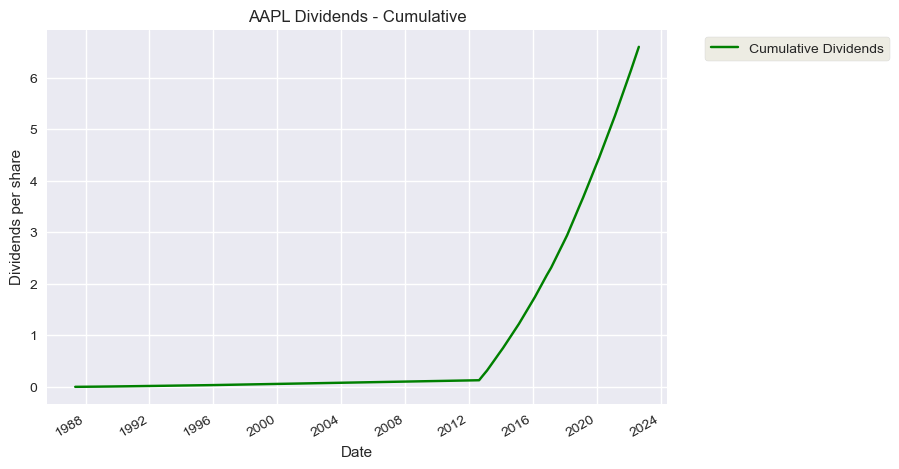

In [46]:
df.loc[df.Dividends != 0].Dividends.cumsum().plot(label = "Cumulative Dividends" , color = "green")
plt.title("AAPL Dividends - Cumulative")
plt.xlabel("Date")
plt.ylabel("Dividends per share")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left" , frameon = True , facecolor = "#e9e8dd")
plt.show()

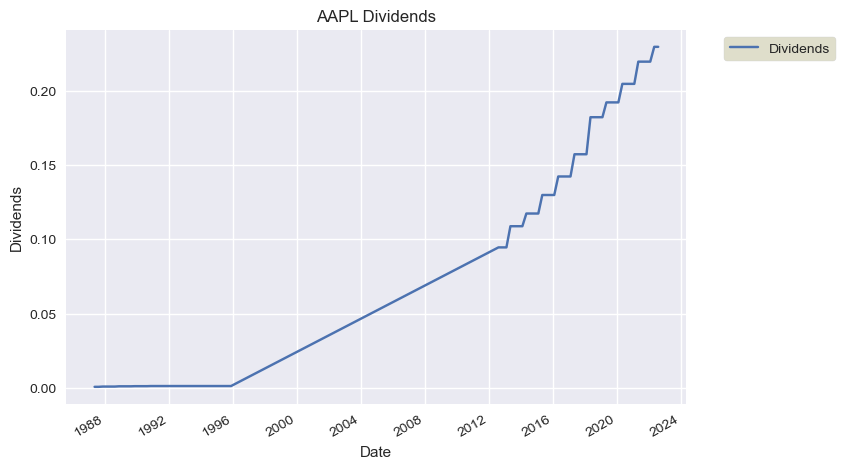

In [47]:
df.loc[df.Dividends != 0].Dividends.plot(label = "Dividends")
plt.title("AAPL Dividends")
plt.xlabel("Date")
plt.ylabel("Dividends")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left" , frameon = True , facecolor = "#d7d6bf")
plt.show()

```python
# 1. Fetch data
ticker = yf.Ticker("AAPL")
divs = ticker.dividends # Returns a series indexed by date

# 2. FIX THE GRAPH: Create a continuous daily timeline spanning the whole history
full_timeline = pd.date_range(start=divs.index.min(), end=divs.index.max(), freq='D')

# 3. Reindex and forward-fill values, then fill the true 1995-2012 gap with 0
# yfinance dividends are sparse; we ffill short gaps but need to catch the absolute zero era
df_divs = pd.DataFrame(index=full_timeline)
df_divs['Dividend_Amount'] = divs

# Since dividends are quarterly payouts, forward-fill for a few months, 
# but if a gap is longer than 365 days (like the 17 year gap), it will remain NaN
df_divs['Clean_Dividends'] = df_divs['Dividend_Amount'].ffill(limit=120).fillna(0)

# 4. Plot the accurate chart
plt.plot(df_divs.index, df_divs['Clean_Dividends'])
plt.title("Accurate AAPL Dividend History (Showing the Real 17-Year Drop to Zero)")
plt.show()
```


In [48]:
ticker = yf.Ticker("AAPL")
divs = ticker.dividends # Returns a series indexed by date

In [49]:
divs.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 91 entries, 1987-05-11 09:30:00-04:00 to 2026-05-11 09:30:00-04:00
Series name: Dividends
Non-Null Count  Dtype  
--------------  -----  
91 non-null     float64
dtypes: float64(1)
memory usage: 3.5 KB


In [50]:
divs.index.min() # Earliest Dividend Date


Timestamp('1987-05-11 09:30:00-0400', tz='America/New_York')

In [51]:
divs.index.max() # Latest Dividend Date()

Timestamp('2026-05-11 09:30:00-0400', tz='America/New_York')

In [52]:
full_timeline = pd.date_range(start=divs.index.min(), end=divs.index.max(), freq='D')


In [53]:
df_divs = pd.DataFrame(index=full_timeline)

In [54]:
df_divs['Dividend_Amount'] = divs

In [55]:
df_divs

,Dividend_Amount
1987-05-11 09:30:00-04:00,0.000536
1987-05-12 09:30:00-04:00,NaN
1987-05-13 09:30:00-04:00,NaN
1987-05-14 09:30:00-04:00,NaN
1987-05-15 09:30:00-04:00,NaN
...,...
2026-05-07 09:30:00-04:00,NaN
2026-05-08 09:30:00-04:00,NaN
2026-05-09 09:30:00-04:00,NaN
2026-05-10 09:30:00-04:00,NaN


In [56]:
df_divs["Dividend_Amount"].value_counts(dropna=False)

Dividend_Amount
NaN         14155
0.001071       21
0.142500        4
0.240000        4
0.230000        4
0.220000        4
0.205000        4
0.192500        4
0.182500        4
0.157500        4
0.130000        4
0.260000        4
0.117500        4
0.108929        4
0.000982        4
0.000893        4
0.000714        4
0.250000        4
0.094643        3
0.000536        2
0.270000        1
Name: count, dtype: int64

In [57]:
df_divs['Clean_Dividends'] = df_divs['Dividend_Amount'].ffill(limit=120).fillna(0)


Universal Limit Selection Guide:📅 <br>
Monthly Payouts: Use limit=45📅 <br>
Quarterly Payouts: Use limit=120📅 <br> 
Semi-Annual Payouts: Use limit=210📅 <br>
Annual Payouts: Use limit=400

In [58]:
df_divs

,Dividend_Amount,Clean_Dividends
1987-05-11 09:30:00-04:00,0.000536,0.000536
1987-05-12 09:30:00-04:00,NaN,0.000536
1987-05-13 09:30:00-04:00,NaN,0.000536
1987-05-14 09:30:00-04:00,NaN,0.000536
1987-05-15 09:30:00-04:00,NaN,0.000536
...,...,...
2026-05-07 09:30:00-04:00,NaN,0.260000
2026-05-08 09:30:00-04:00,NaN,0.260000
2026-05-09 09:30:00-04:00,NaN,0.260000
2026-05-10 09:30:00-04:00,NaN,0.260000


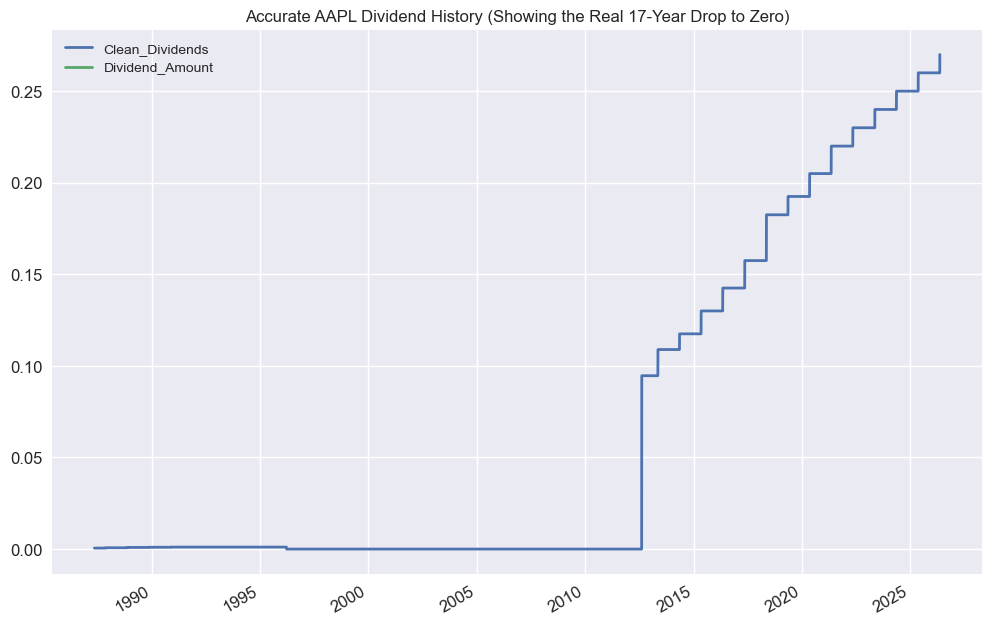

In [59]:
df_divs[["Clean_Dividends", "Dividend_Amount"]].plot(figsize = (12, 8), fontsize = 12, linewidth = 2)
plt.title("Accurate AAPL Dividend History (Showing the Real 17-Year Drop to Zero)")
plt.show()

AAPL Dividend Policy:
* 1. The Early Years (1988 – 1996)<br>
The blue line sits flat, right near $0.00. This is historically accurate; Apple paid a tiny, split-adjusted token dividend during this period before entering severe financial trouble in the mid-1990s.
* 2. The Steve Jobs Era Gap (1996 – 2012) <br> The IllusionThe perfectly smooth, diagonal line slanting upward from 1996 to 2012 is a visual error caused by your data structure.<br>
The Reality: Apple did not gradually increase its dividend over these 16 years. <br>
Steve Jobs completely suspended the dividend in 1995 to conserve capital and refused to reinstate it, preference-building a massive cash hoard instead The Guardian.
* 3. The Tim Cook Era (2012 – 2024)<br>
The graph shifts into a clean stair-step pattern. This accurately reflects modern times: after Jobs passed, CEO Tim Cook reinstated the quarterly dividend in 2012. The horizontal flat zones are the quarters where the dividend stayed the same, and the vertical jumps show Apple's annual tradition of raising the payout every spring.

-> AAPL Dividend Policy: 
- historically __low-dividend__ stock (focus on growth) : Apple 
- Dividend Payouts __smoothed and steadily growing__ (highly predictable)
- __Avoiding Dividend Cuts__ in less profitable years (negative signal in the market)

## What´s the Adjusted Close Price?

"The Adjusted Close Price is the backward adjusted (reduced) Close Price (adjusted for Dividends)."   

In [60]:
df = pd.read_csv("aapl.csv", index_col = "Date", parse_dates = ["Date"])
df


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


In [61]:
df2 = df[["Close", "Adj Close", "Dividends"]].copy()
df2

,Close,Adj Close,Dividends
Date,,,
1980-12-12,0.128348,0.100039,0.0
1980-12-15,0.121652,0.094820,0.0
1980-12-16,0.112723,0.087861,0.0
1980-12-17,0.115513,0.090035,0.0
1980-12-18,0.118862,0.092646,0.0
...,...,...,...
2022-10-17,142.410004,142.410004,0.0
2022-10-18,143.750000,143.750000,0.0
2022-10-19,143.860001,143.860001,0.0


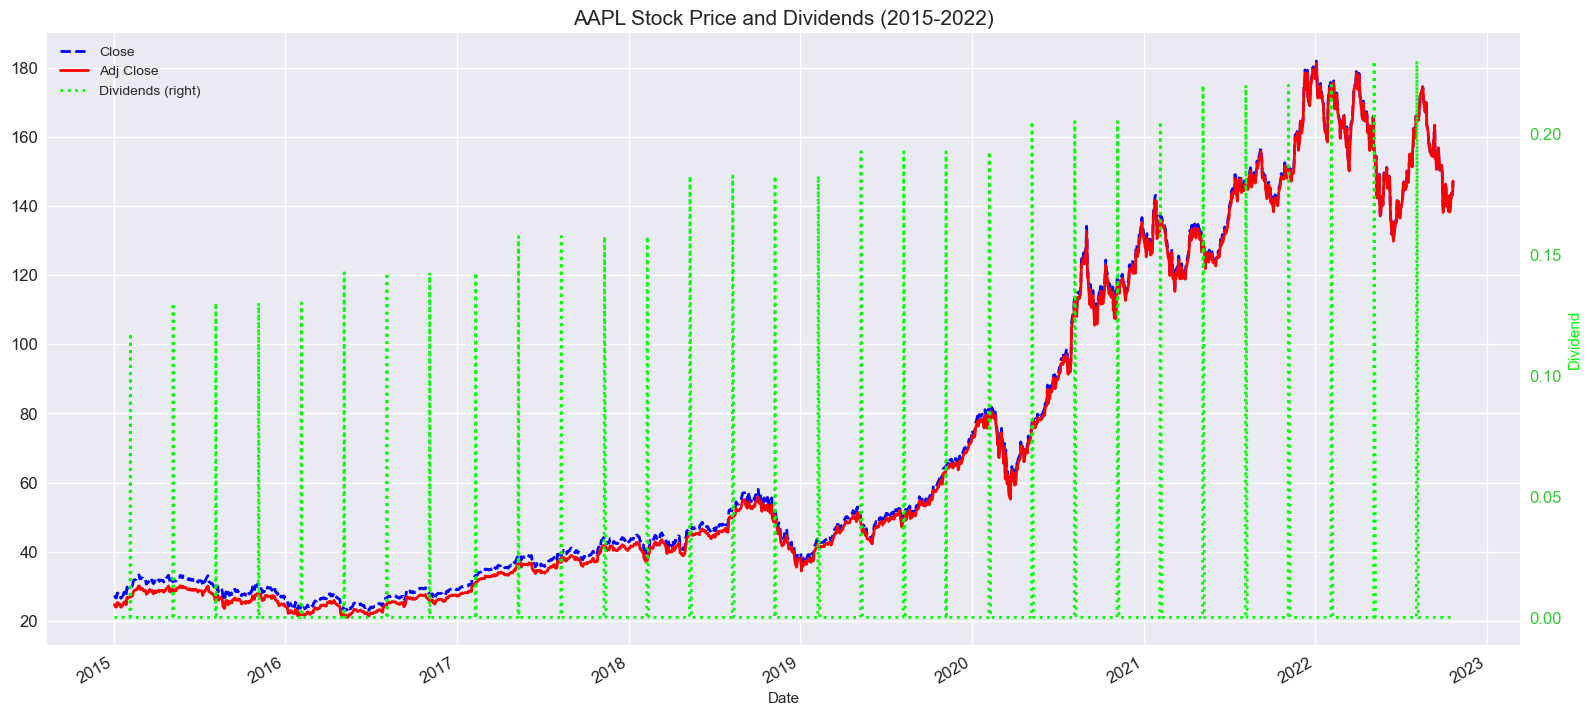

In [62]:
df2.loc["2015":].plot(figsize = (19,9), secondary_y = "Dividends" , color = ["blue", "red", "lime"],style = ["--","-",":"], fontsize = 12, linewidth = 2)
plt.title("AAPL Stock Price and Dividends (2015-2022)", fontsize = 15)
plt.xlabel("Date")
plt.ylabel("Dividend" , color ="lime")
plt.tick_params(axis='y', labelcolor="limegreen")
plt.show()

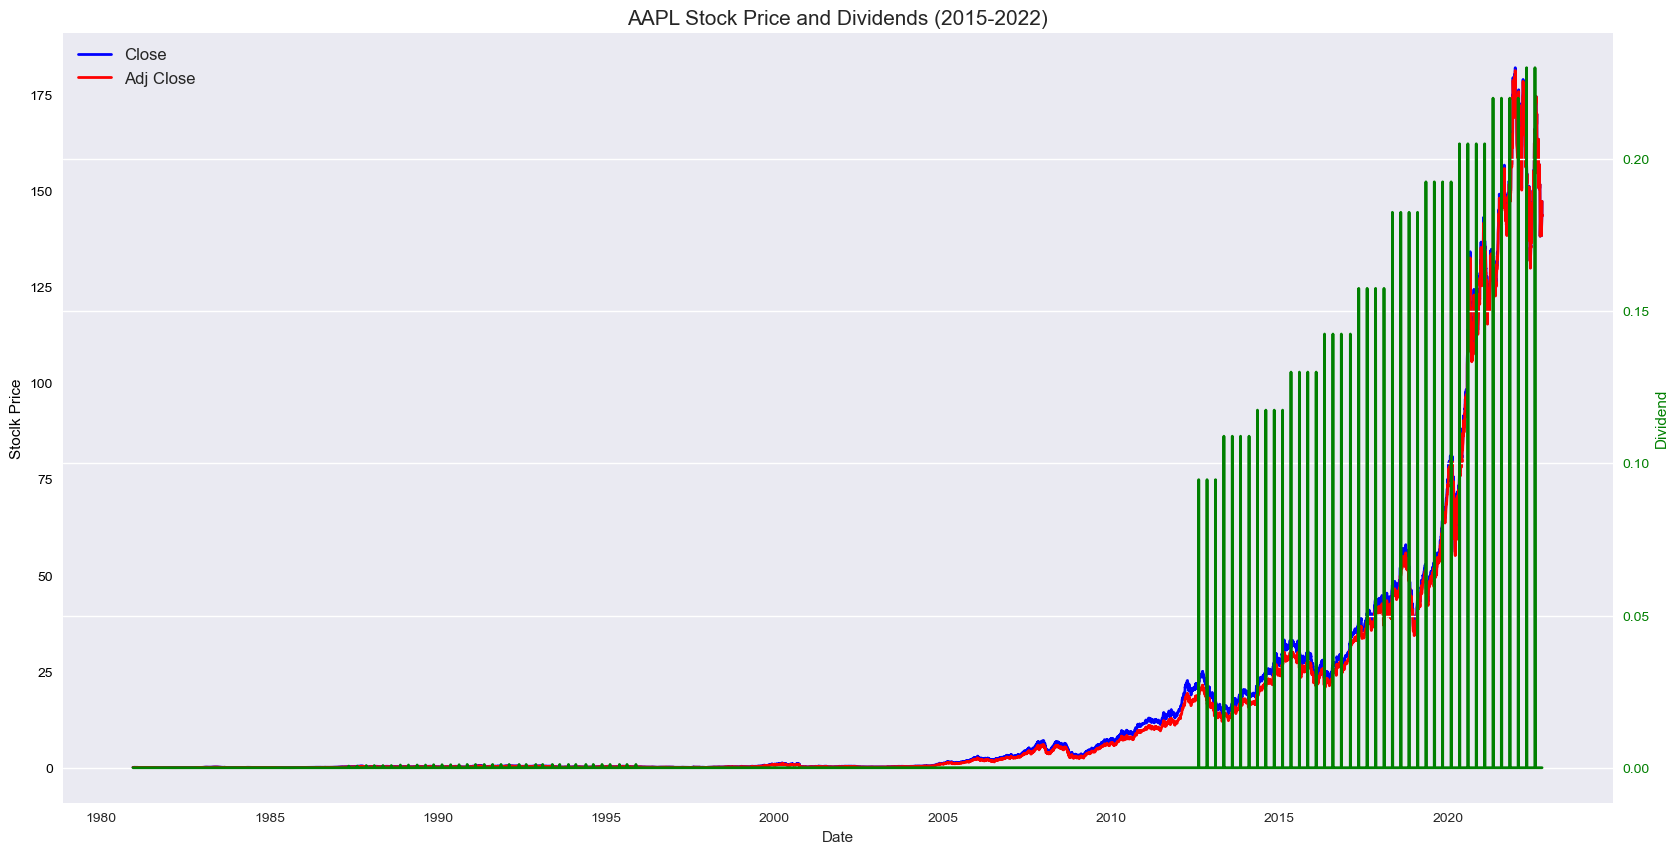

In [63]:
fig , ax = plt.subplots(figsize = (20, 10))

ax.plot(df2.index, df2.Close, color = "blue", linewidth = 2)
ax.plot(df2.index, df2["Adj Close"], color = "red", linewidth = 2)
ax.set_title("AAPL Stock Price and Dividends (2015-2022)", fontsize = 15)
ax.set_xlabel("Date")
ax.set_ylabel("Stoclk Price" , color = "black")
ax.tick_params(axis='y', labelcolor="black")
ax.grid(False)
ax.legend(["Close", "Adj Close", "Dividends"], fontsize = 12)


ax2 = ax.twinx()
ax2.plot(df2.index, df2.Dividends, color = "green", linewidth = 2)
ax2.set_ylabel("Dividend" , color = "green")
ax2.tick_params(axis='y', labelcolor="green")



plt.show()

In [64]:
df2[df2.Dividends > 0]

,Close,Adj Close,Dividends
Date,,,
1987-05-11,0.343750,0.268340,0.000536
1987-08-10,0.430804,0.336732,0.000536
1987-11-17,0.312500,0.244794,0.000714
1988-02-12,0.366071,0.287323,0.000714
1988-05-16,0.368304,0.289648,0.000714
...,...,...,...
2021-08-06,146.139999,145.325668,0.220000
2021-11-05,151.279999,150.656570,0.220000
2022-02-04,172.389999,171.898315,0.220000


In [65]:
last_div = df2.loc["2022-08-01": "2022-08-5"].copy()
last_div

,Close,Adj Close,Dividends
Date,,,
2022-08-01,161.509995,161.285965,0.00
2022-08-02,160.009995,159.788040,0.00
2022-08-03,166.130005,165.899567,0.00
2022-08-04,165.809998,165.580002,0.00
2022-08-05,165.350006,165.350006,0.23


In [66]:
last_div.Close - last_div["Adj Close"]

Date
2022-08-01    0.224030
2022-08-02    0.221954
2022-08-03    0.230438
2022-08-04    0.229996
2022-08-05    0.000000
dtype: float64

In [67]:
1 - (last_div.Dividends.iloc[-1]/last_div.Close.iloc[-1])

np.float64(0.9986090112397334)

$$\text{Multiplier} = 1 - \frac{\text{Last dividend}}{\text{Last Closing Price}}$$

$$ \text{df["Adj Close"]} = \text{df["Close"]} \times\text{Multiplier}$$


For more information on multiplier calculation, visit: 
<a href = "https://in.help.yahoo.com/kb/adjusted-close-sln28256.html">What is the adjusted close?<a>

In [68]:
multiplier = (1 - 0.23/165.809998) # = 1 - (last_div.Dividends/last_div.Close)
multiplier

0.9986128701358528

In [69]:
last_div

,Close,Adj Close,Dividends
Date,,,
2022-08-01,161.509995,161.285965,0.00
2022-08-02,160.009995,159.788040,0.00
2022-08-03,166.130005,165.899567,0.00
2022-08-04,165.809998,165.580002,0.00
2022-08-05,165.350006,165.350006,0.23


In [70]:
last_div["Adj Close calc"] = last_div.Close * multiplier
last_div

,Close,Adj Close,Dividends,Adj Close calc
Date,,,,
2022-08-01,161.509995,161.285965,0.00,161.285959
2022-08-02,160.009995,159.788040,0.00,159.788040
2022-08-03,166.130005,165.899567,0.00,165.899561
2022-08-04,165.809998,165.580002,0.00,165.579998
2022-08-05,165.350006,165.350006,0.23,165.120644


To see all the multipliers we can use the following formula:

$$\text{Multiplier}  = \frac{\text{df["Adj Close"]}}{\text{df["Close"]}}$$

In [71]:
df["Adj Close"] / df["Close"] # total multiplier (all dividends)

Date
1980-12-12    0.779439
1980-12-15    0.779440
1980-12-16    0.779439
1980-12-17    0.779440
1980-12-18    0.779439
                ...   
2022-10-17    1.000000
2022-10-18    1.000000
2022-10-19    1.000000
2022-10-20    1.000000
2022-10-21    1.000000
Length: 10555, dtype: float64

In [72]:
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


In [73]:
df["Dividends_Multiplier"] = df["Adj Close"] / df["Close"]

In [74]:
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Dividends_Multiplier
Date,,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0,0.779439
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0,0.779440
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0,0.779439
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0,0.779440
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0,0.779439
...,...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0,1.000000
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0,1.000000
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0,1.000000


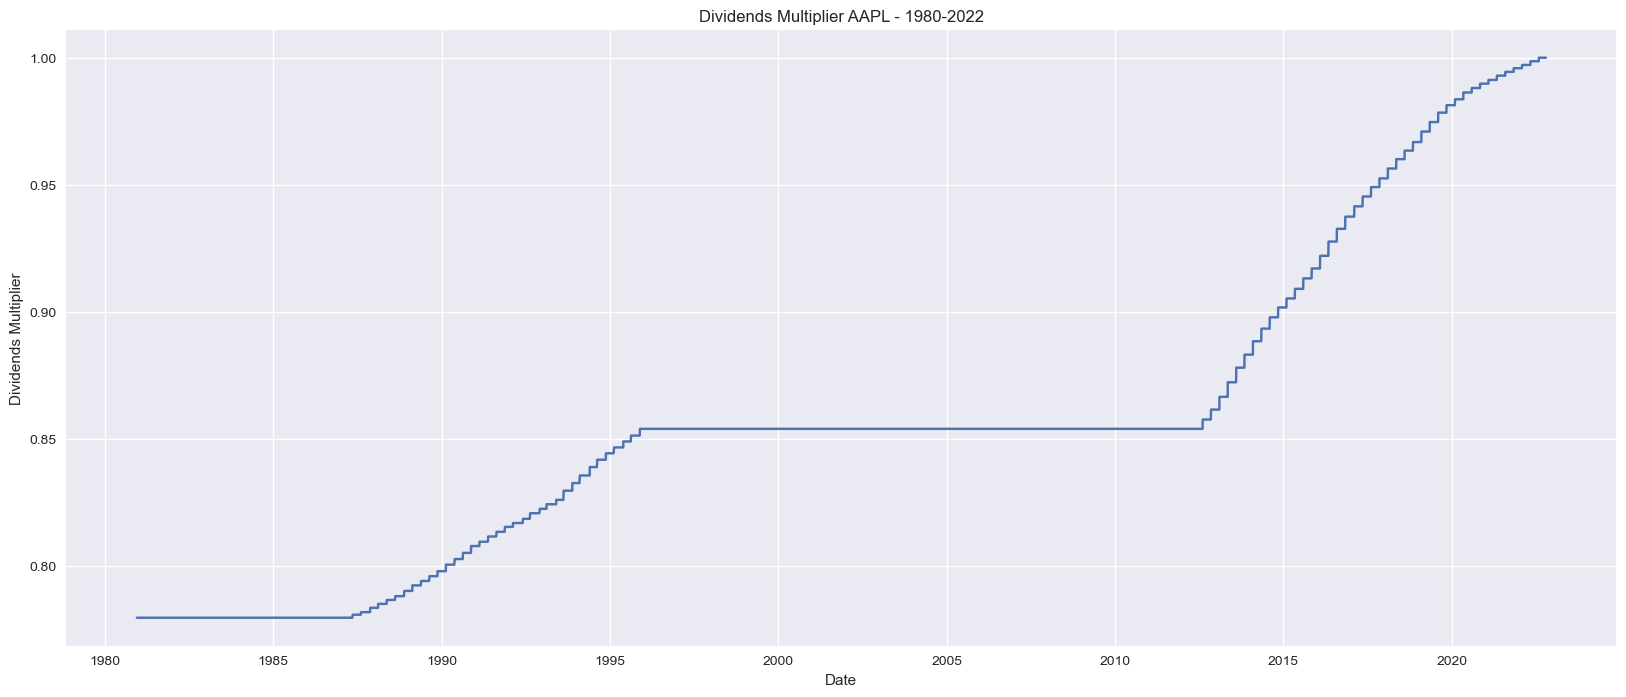

In [75]:
plt.figure(figsize = (20,8))
plt.plot(df["Dividends_Multiplier"])
plt.title("Dividends Multiplier AAPL - 1980-2022")
plt.xlabel("Date")
plt.ylabel("Dividends Multiplier")
plt.show()

In [76]:
np.around(1- df["Dividends_Multiplier"] , 2)*100

Date
1980-12-12    22.0
1980-12-15    22.0
1980-12-16    22.0
1980-12-17    22.0
1980-12-18    22.0
              ... 
2022-10-17     0.0
2022-10-18     0.0
2022-10-19     0.0
2022-10-20     0.0
2022-10-21     0.0
Name: Dividends_Multiplier, Length: 10555, dtype: float64

In [77]:
# How can I interpret this?
# It means that the dividends are 22% of the total price of the stock at that point in time. 
# so if the stock price is 100, then the dividends are 22% of 100, or 22 dollars which means we 

__Interpretations:__
- Borrowing parts (e.g. 22%) of initial stock purchase price in 1980 and pay back borrowed amounts with Dividends. -or-
- Reinvesting Dividends and buying more shares with Dividends

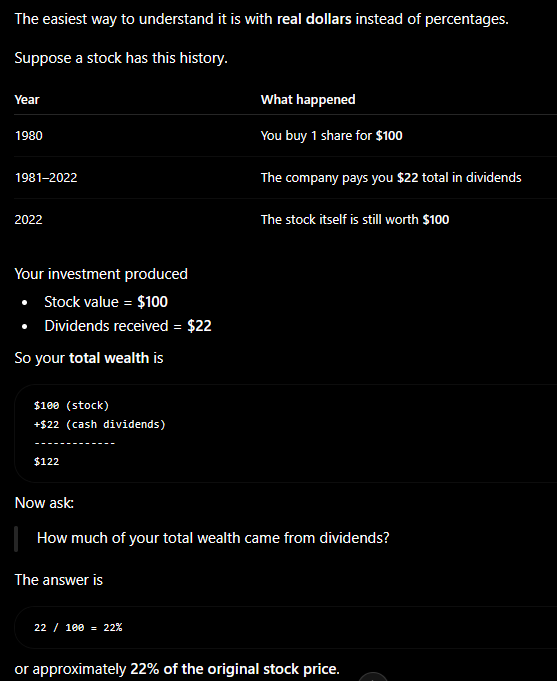

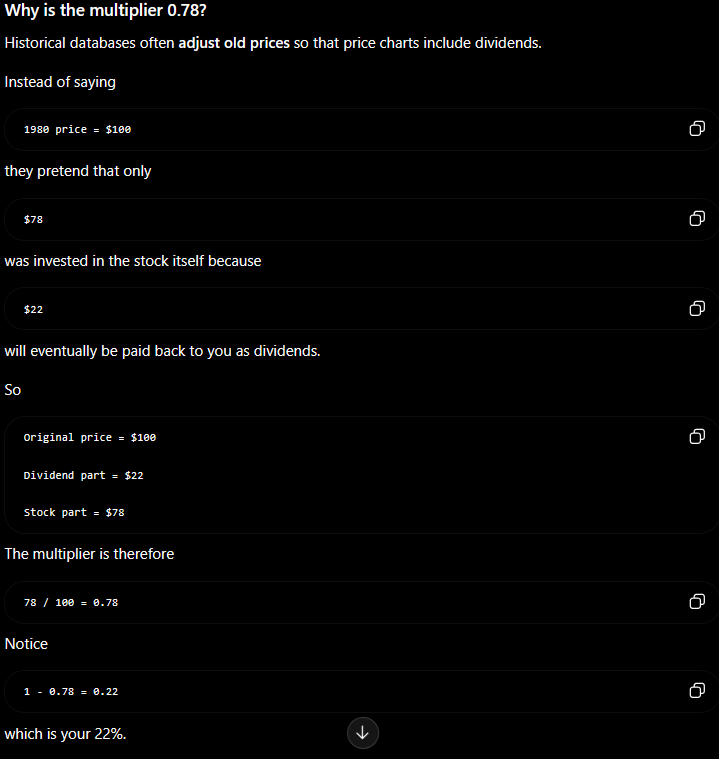

__Benefits:__
- good approximation for a Stock´s __Total Return__ (Price Return + Dividend Yield)
- allows __Performance Comparison__ across stocks with different Payout Policies

## Stock Splits

In [78]:
df = pd.read_csv("aapl.csv", index_col = "Date", parse_dates = ["Date"])
df


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


All Prices (OHLC, Adj Close) and Dividends are __backward adjusted__ (reduced) for Stock Splits. 

-> This __makes perfectly sense__ and you should not question it (unless you are interested in historical observable prices)!

In [79]:
splits = df.loc[df["Stock Splits"] > 0]
splits

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1987-06-16,0.370536,0.372768,0.339286,0.370536,0.289250,342720000,0.0,2.0
2000-06-21,0.901786,1.016741,0.898438,0.993304,0.848115,490000000,0.0,2.0
2005-02-28,1.595714,1.612143,1.570000,1.602143,1.367960,651610400,0.0,2.0
2014-06-09,23.174999,23.469999,22.937500,23.424999,20.925592,301660000,0.0,7.0
2020-08-31,127.580002,131.000000,126.000000,129.039993,127.500870,225702700,0.0,4.0


__Stock Split__: allows a company to break (split) each share into multiple shares __without affecting its market capitalization (total value of all its shares) or each investor's stake__ in the company. Motivation: reduce price per share and increase granularity.

__Example Stock Split 4:1__ -> Receive 4 new shares for 1 old share. Share Price immediately drops to 1/4 (no value effect)

On Yahoo Finance, Prices & Dividends are backward adjusted for Stock Splits. 

Price on 2020-08-31 __after Split__:

In [80]:
splits.loc["2020-08-31", "Close"] 

np.float64(129.0399932861328)

Price on 2020-08-31 __before Split__:

In [81]:
splits.loc["2020-08-31", "Close"] * splits.loc["2020-08-31", "Stock Splits"]

np.float64(516.1599731445312)

__-> 4 * 129 == 1 * 516__

__Calculate the unadjusted (observable) prices__

In [82]:
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


In [83]:
df["Stock Splits"].value_counts()

Stock Splits
0.0    10550
2.0        3
7.0        1
4.0        1
Name: count, dtype: int64

In [84]:
df["Stock Splits"].replace(to_replace = 0, value = 1).value_counts()

Stock Splits
1.0    10550
2.0        3
7.0        1
4.0        1
Name: count, dtype: int64

In [85]:
df["Stock Splits"] = df["Stock Splits"].replace(to_replace = 0, value = 1) # 1:1 on all other days

In [86]:
df["Stock Splits"].value_counts()

Stock Splits
1.0    10550
2.0        3
7.0        1
4.0        1
Name: count, dtype: int64

In [87]:
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0


In [88]:
df.sort_index(ascending = False)

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2022-10-21,142.869995,147.850006,142.649994,147.270004,147.270004,86464700,0.0,1.0
2022-10-20,143.020004,145.889999,142.649994,143.389999,143.389999,64522000,0.0,1.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0
...,...,...,...,...,...,...,...,...
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0


In [89]:
df["Multiplier"] = df.sort_index(ascending = False)["Stock Splits"].cumprod() # cumulative multipier: 1:1 on all other days 
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Multiplier
Date,,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0,224.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0,224.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0,224.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0,224.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0,224.0
...,...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0,1.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0,1.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0,1.0


In [90]:
df["Close_unadj"] = df["Close"] * df.Multiplier # observable close price
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Multiplier,Close_unadj
Date,,,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0,224.0,28.749950
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0,224.0,27.250048
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0,224.0,25.249952
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0,224.0,25.874911
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0,224.0,26.625089
...,...,...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0,1.0,142.410004
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0,1.0,143.750000
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0,1.0,143.860001


So, Apple traded around $28.75 in December 1980. After its cumulative 224:1 stock splits, that same historical price is shown as about $0.128 in today's split-adjusted data.<br>

So:<br>
Adjusted (split-adjusted) close: $0.128 ← useful for return analysis. <br>
Unadjusted (original) close: $28.75 ← the price investors actually saw in 1980.

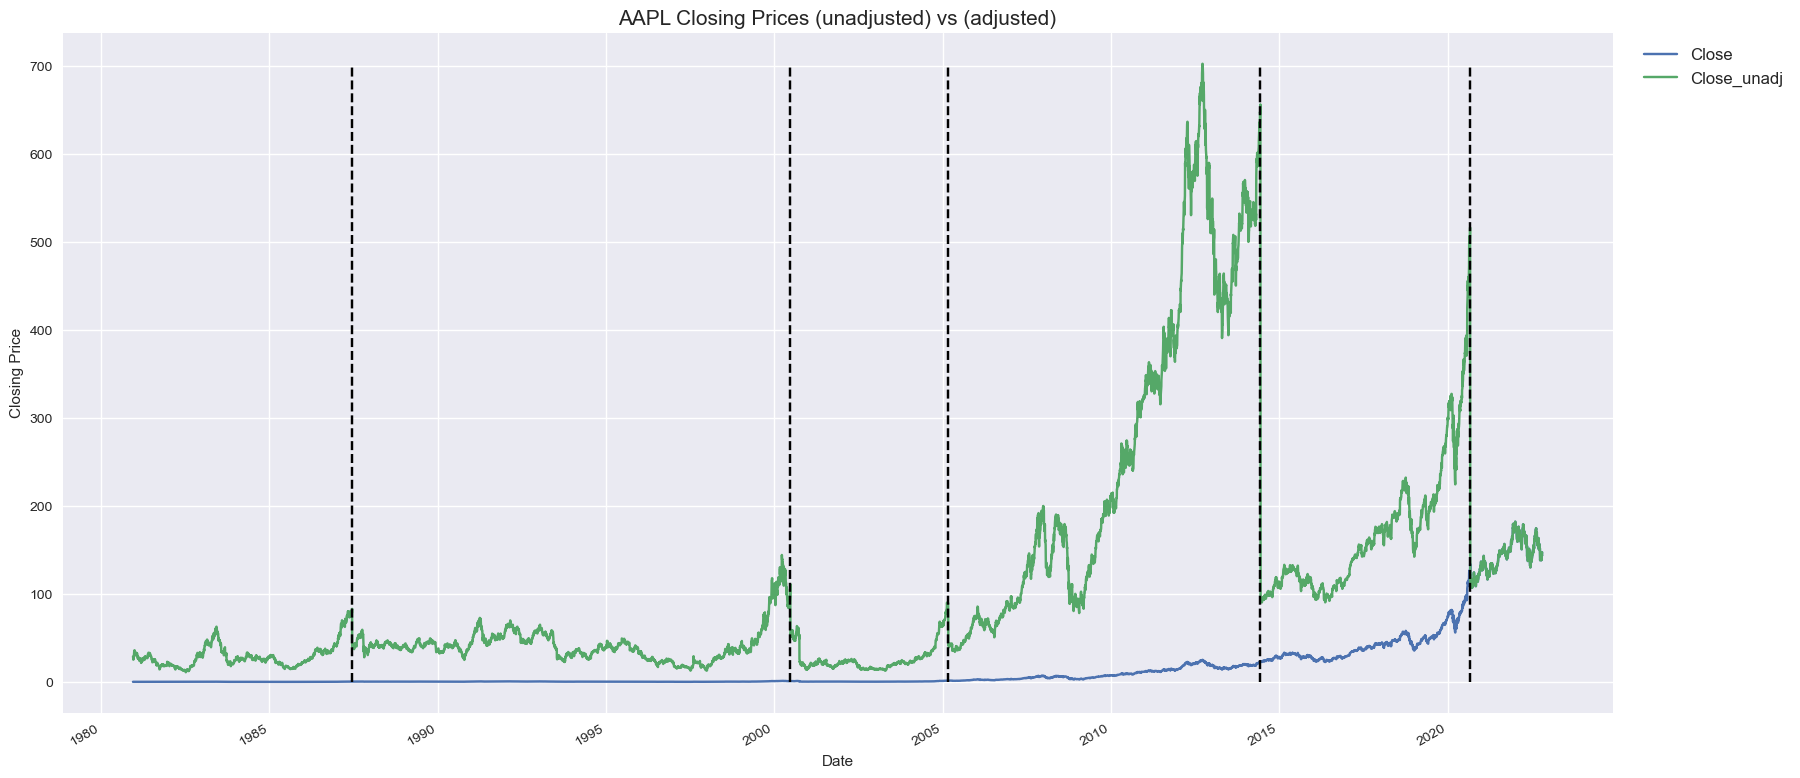

In [91]:
df[["Close", "Close_unadj"]].plot(figsize = (20, 10))
plt.title("AAPL Closing Prices (unadjusted) vs (adjusted)", fontsize = 15)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.vlines(splits.index, 0, 700, color = "black" ,ls = "--")
plt.legend(["Close", "Close_unadj"],bbox_to_anchor=(1.12 , 1), fontsize = 12)
plt.show()

__-> (backward adjusted) prices correctly reflect true price performance. They ignore price drops caused by stock splits!__

__unadjusted Dividends__

In [92]:
df["div_unadj"] = df["Dividends"] * df.Multiplier

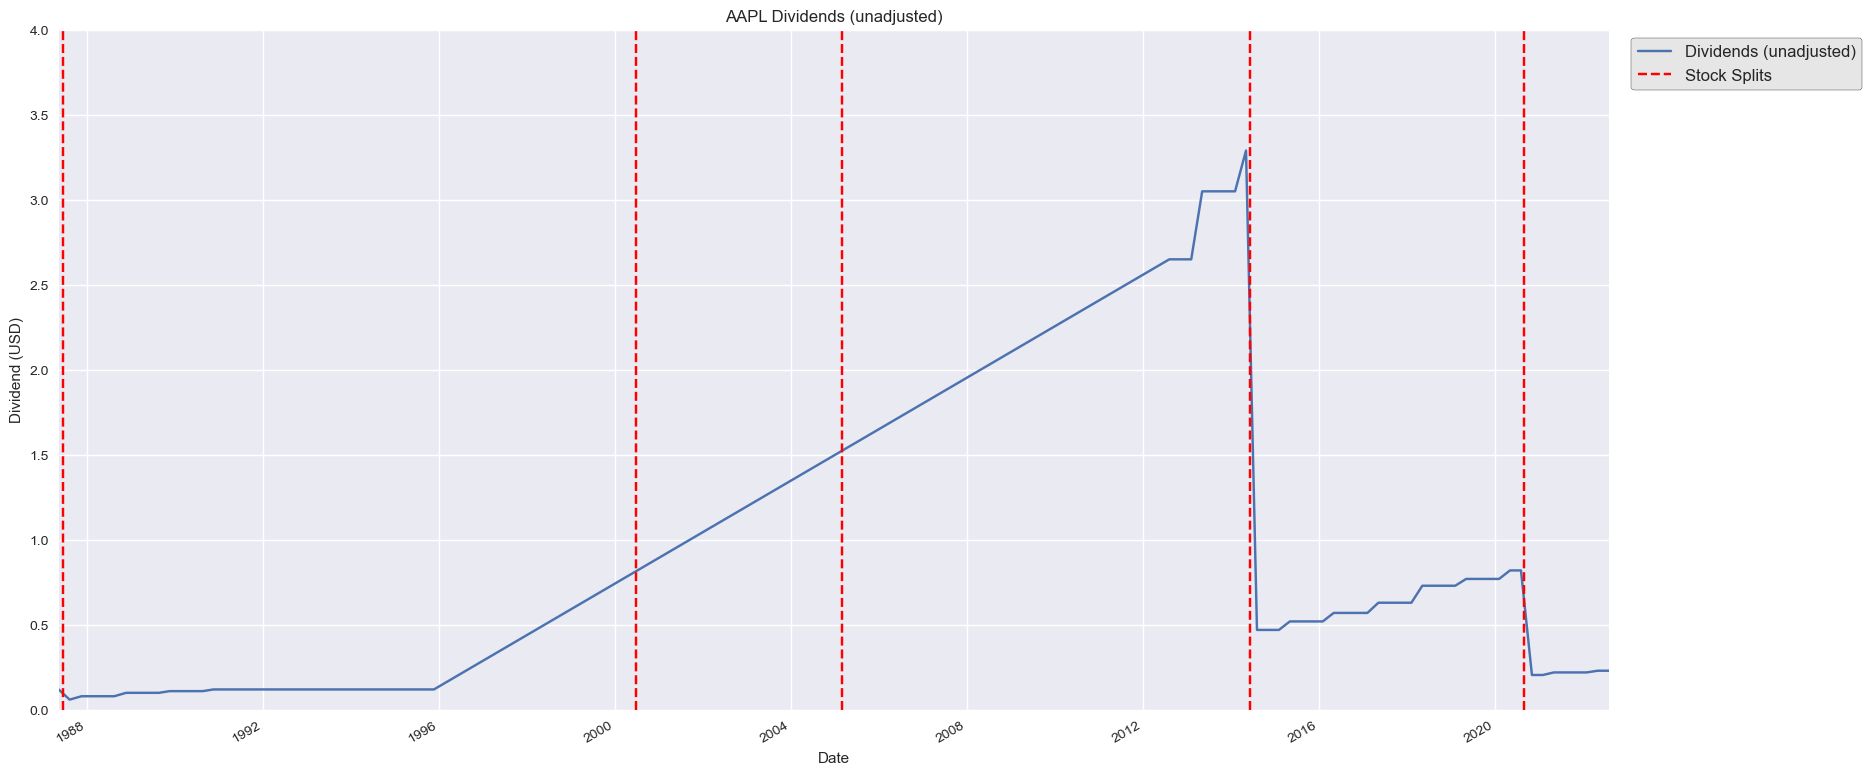

In [93]:
df.loc[df.div_unadj != 0].div_unadj.plot(figsize = (20, 10))
plt.vlines(splits.index, 0, 4, color = "red" ,ls = "--")
plt.ylabel("Dividend (USD)")
plt.title("AAPL Dividends (unadjusted)")
plt.xlabel("Date")
plt.autoscale(enable = True, axis = "both", tight = True)
plt.legend(["Dividends (unadjusted)", "Stock Splits"],bbox_to_anchor=(1.169 , 1), fontsize = 12 , frameon = True , facecolor = "#e0e0e0" , edgecolor = "black", fancybox = True)
plt.show()

__unadjusted Trading Volume (number of shares)__

In [94]:
df["Volume_unadj"] = df["Volume"] / df.Multiplier

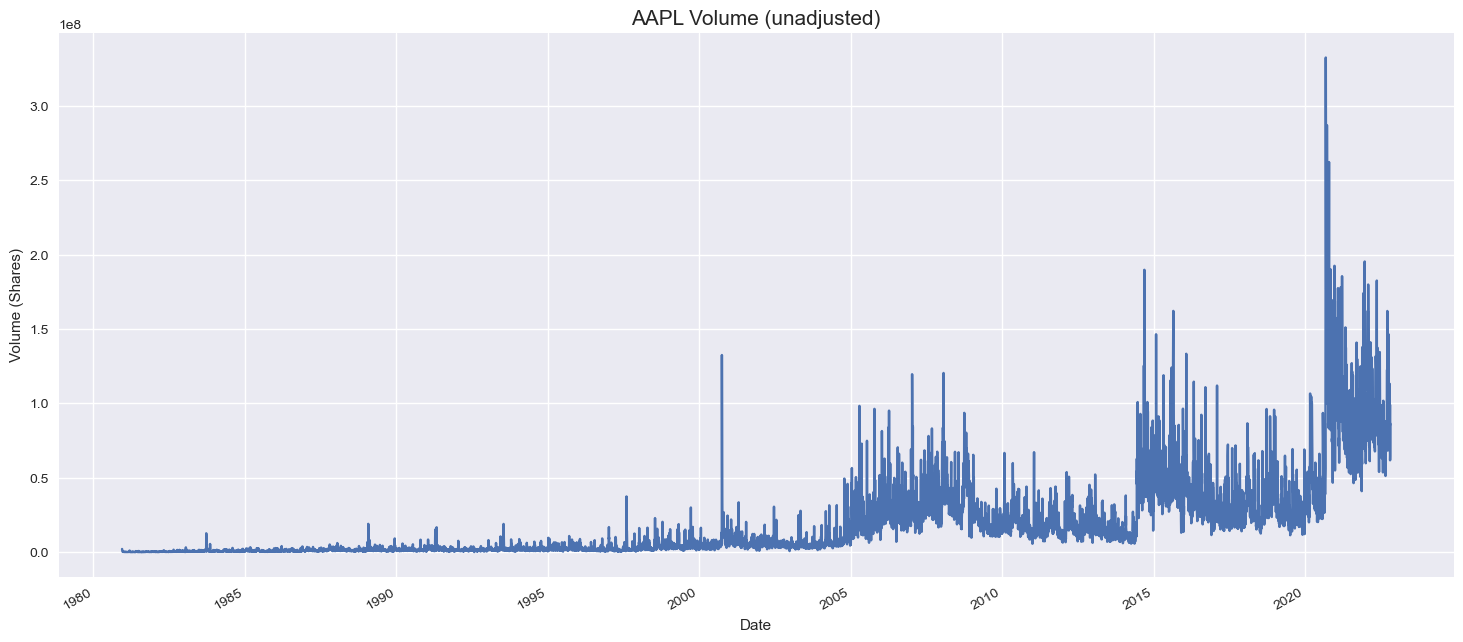

In [95]:
df["Volume_unadj"].plot(figsize = (18, 8))
plt.title("AAPL Volume (unadjusted)", fontsize = 15)
plt.xlabel("Date")
plt.ylabel("Volume (Shares)")
plt.show()

## Stocks from other Countries / Exchanges 

In [96]:
yf.download(tickers = "AAPL") # US Ticker (no suffix)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


In [97]:
yf.download(tickers = "RELIANCE") # Indian Ticker (no suffix)

$RELIANCE: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RELIANCE']: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE,RELIANCE,RELIANCE,RELIANCE,RELIANCE,RELIANCE


__Exchange List:__ 

You can find more information like a table of the countries with their suffix to get their data:<br>

<a href="https://help.yahoo.com/kb/SLN2310.html">Exchanges and data providers on Yahoo Finance</a>

In [98]:
global_stock_exchanges = pd.read_html(io = "https://help.yahoo.com/kb/SLN2310.html")[0]
global_stock_exchanges.set_index("Country", inplace = True)

In [99]:
global_stock_exchanges

,"Market, or Index",Suffix,Delay,Data Provider
Country,,,,
United States of America,Blue Ocean ATS (BOATS),NaN,Real-time,ICE Data Services
United States of America,Cboe Indices,NaN,15 min,ICE Data Services
United States of America,Chicago Board of Trade (CBOT)***,.CBT,10 min,ICE Data Services
United States of America,Chicago Mercantile Exchange (CME)***,.CME,10 min,ICE Data Services
United States of America,Dow Jones Indexes,NaN,Real-time,ICE Data Services
...,...,...,...,...
United Kingdom,FTSE Indices,NaN,15 min,ICE Data Services
United Kingdom,London Stock Exchange,.L,20 min,ICE Data Services
United Kingdom,London Stock Exchange,.IL,20 min,ICE Data Services


In [100]:
country_finder_mask = global_stock_exchanges.index.str.lower().str.contains("in")
country_finder_mask

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True, False, False])

In [101]:
global_stock_exchanges.loc[country_finder_mask]

,"Market, or Index",Suffix,Delay,Data Provider
Country,,,,
Argentina,Buenos Aires Stock Exchange (BYMA),.BA,30 min,ICE Data Services
China,Shanghai Stock Exchange,.SS,30 min,ICE Data Services
China,Shenzhen Stock Exchange,.SZ,30 min,ICE Data Services
Finland,Nasdaq OMX Helsinki,.HE,Real-time,ICE Data Services
India,Bombay Stock Exchange,.BO,15 min,ICE Data Services
India,National Stock Exchange of India,.NS,Real-time,ICE Data Services
Indonesia,Indonesia Stock Exchange (IDX),.JK,10 min,ICE Data Services
Philippines,Philippine Stock Exchange Indices,.PS,15 min,ICE Data Services
Singapore,Singapore Stock Exchange (SGX),.SI,20 min,ICE Data Services


In [102]:
global_stock_exchanges.loc["India", ["Market, or Index", "Suffix"]]

,"Market, or Index",Suffix
Country,,
India,Bombay Stock Exchange,.BO
India,National Stock Exchange of India,.NS


Let's wrap up the above arguments and define a makret finder function:

In [103]:
def market_finder(country_name: str) -> pd.DataFrame:
    global_stock_exchanges = pd.read_html(io = "https://help.yahoo.com/kb/SLN2310.html")[0]
    global_stock_exchanges.set_index("Country", inplace = True)
    country_finder_mask = global_stock_exchanges.index.str.lower().str.contains(country_name.lower())
    return global_stock_exchanges.loc[country_finder_mask]


In [104]:
market_finder("India")  

,"Market, or Index",Suffix,Delay,Data Provider
Country,,,,
India,Bombay Stock Exchange,.BO,15 min,ICE Data Services
India,National Stock Exchange of India,.NS,Real-time,ICE Data Services


In [105]:
yf.download(tickers = "RELIANCE.NS") # Indian Ticker

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-06-08,1263.300049,1282.599976,1259.199951,1277.000000,16494759
2026-06-09,1269.199951,1274.199951,1257.500000,1269.000000,23620214
2026-06-10,1258.800049,1300.500000,1254.400024,1275.000000,21012796
2026-06-11,1263.000000,1276.000000,1253.199951,1258.000000,13117486
2026-06-12,1293.000000,1297.000000,1262.500000,1277.000000,11988785
2026-06-15,1307.000000,1325.000000,1303.300049,1315.300049,18633321
2026-06-16,1328.800049,1333.400024,1306.400024,1313.400024,18513223
2026-06-17,1332.699951,1334.000000,1317.000000,1333.000000,10029170


In [106]:
yf.download(tickers = "LHA.DE") # German Ticker (Deutsche Boerse XETRA)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,LHA.DE,LHA.DE,LHA.DE,LHA.DE,LHA.DE
Date,,,,,
2026-06-08,8.280,8.474,8.116,8.214,4443764
2026-06-09,8.092,8.364,8.076,8.234,6065090
2026-06-10,8.044,8.140,7.954,8.090,4622406
2026-06-11,8.030,8.086,7.914,7.988,3867061
2026-06-12,8.446,8.682,8.322,8.322,11370810
2026-06-15,8.828,9.000,8.770,8.900,7665880
2026-06-16,8.910,8.966,8.810,8.860,5049232
2026-06-17,8.886,9.070,8.728,8.938,6631330


In [107]:
yf.download(tickers = "LHA.F") # German Ticker (Frankfurt Stock Exchange)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,LHA.F,LHA.F,LHA.F,LHA.F,LHA.F
Date,,,,,
2026-06-08,8.256,8.424,8.174,8.200,8775
2026-06-09,8.086,8.326,8.036,8.210,15422
2026-06-10,8.070,8.124,8.000,8.124,9525
2026-06-11,8.214,8.214,7.920,8.082,21160
2026-06-12,8.556,8.670,8.278,8.278,62748
2026-06-15,8.778,8.994,8.750,8.850,86636
2026-06-16,8.900,8.948,8.808,8.850,20853
2026-06-17,8.870,9.010,8.776,8.850,41630


## Multiple Tickers

In [108]:
df = yf.download(tickers = ["AAPL", "MSFT"]) # multiple tickers
df

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.519196  385.750000  314.200012  389.149994  307.010010   

Price                         Open                 Volume             
Ticker            MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27204498   16892813

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-06-08 to 2026-07-06
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   19 non-null     float64
 1   (Close, MSFT)   19 non-null     float64
 2   (High, AAPL)    19 non-null     float64
 3   (High, MSFT)    19 non-null     float64
 4   (Low, AAPL)     19 non-null     float64
 5   (Low, MSFT)     19 non-null     float64
 6   (Open, AAPL)    19 non-null     float64
 7   (Open, MSFT)    19 non-null     float64
 8   (Volume, AAPL)  19 non-null     int64  
 9   (Volume, MSFT)  19 non-null     int64  
dtypes: float64(8), int64(2)
memory usage: 1.6 KB


In [110]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [111]:
df.Close # outer index level

Ticker,AAPL,MSFT
Date,,
2026-06-08,301.540009,411.739990
2026-06-09,290.549988,403.410004
2026-06-10,291.579987,397.359985
2026-06-11,295.630005,390.339996
2026-06-12,291.130005,390.739990
2026-06-15,296.420013,399.760010
2026-06-16,299.239990,393.829987
2026-06-17,295.950012,378.910004
2026-06-18,298.010010,379.399994


In [112]:
df.loc[:, ("Close", "MSFT")] # one specific column

Date
2026-06-08    411.739990
2026-06-09    403.410004
2026-06-10    397.359985
2026-06-11    390.339996
2026-06-12    390.739990
2026-06-15    399.760010
2026-06-16    393.829987
2026-06-17    378.910004
2026-06-18    379.399994
2026-06-22    367.339996
2026-06-23    373.940002
2026-06-24    365.459991
2026-06-25    352.829987
2026-06-26    372.970001
2026-06-29    368.570007
2026-06-30    373.019989
2026-07-01    384.279999
2026-07-02    390.489990
2026-07-06    385.750000
Name: (Close, MSFT), dtype: float64

In [113]:
df.Close.MSFT # one specific column

Date
2026-06-08    411.739990
2026-06-09    403.410004
2026-06-10    397.359985
2026-06-11    390.339996
2026-06-12    390.739990
2026-06-15    399.760010
2026-06-16    393.829987
2026-06-17    378.910004
2026-06-18    379.399994
2026-06-22    367.339996
2026-06-23    373.940002
2026-06-24    365.459991
2026-06-25    352.829987
2026-06-26    372.970001
2026-06-29    368.570007
2026-06-30    373.019989
2026-07-01    384.279999
2026-07-02    390.489990
2026-07-06    385.750000
Name: MSFT, dtype: float64

In [114]:
df.loc[:, (slice(None), slice("AAPL"))] # inner index level

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100


In [115]:
df

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.519196  385.750000  314.200012  389.149994  307.010010   

Price                         Open                 Volume             
Ticker            MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27204498   16892813

In [116]:
df.swaplevel(axis = "columns").sort_index(axis = "columns")

Ticker            AAPL                                                 \
Price            Close        High         Low        Open     Volume   
Date                                                                    
2026-06-08  301.540009  317.399994  301.170013  308.739990   77949100   
2026-06-09  290.549988  300.750000  287.779999  300.279999   70108800   
2026-06-10  291.579987  294.750000  287.380005  290.739990   52793300   
2026-06-11  295.630005  297.000000  289.589996  293.720001   42572500   
2026-06-12  291.130005  297.140015  289.619995  296.029999   38742100   
2026-06-15  296.420013  297.779999  291.700012  294.119995   45732600   
2026-06-16  299.239990  300.480011  293.970001  295.250000   39874400   
2026-06-17  295.950012  302.070007  294.359985  300.850006   42745100   
2026-06-18  298.010010  300.570007  295.619995  298.109985   85962200   
2026-06-22  297.010010  302.420013  296.760010  297.309998   44879900   
2026-06-23  294.299988  301.640015  294.179993  297.540009   52010900   
2026-06-24  293.079987  299.700012  292.940002  295.359985   53081900   
2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700   
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500   
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000   
2026-06-30  289.359985  289.940002  280.700012  281.170013   65100200   
2026-07-01  294.380005  296.589996  289.200012  293.440002   50164200   
2026-07-02  308.630005  309.420013  293.679993  294.119995   75352800   
2026-07-06  312.519196  314.200012  307.010010  307.679993   27204498   

Ticker            MSFT                                                 
Price            Close        High         Low        Open     Volume  
Date                                                                   
2026-06-08  411.739990  417.160004  408.559998  414.140015   32086700  
2026-06-09  403.410004  411.980011  398.480011  409.029999   35317300  
2026-06-10  397.359985  405.040009  397.160004  398.549988   32576000  
2026-06-11  390.339996  396.850006  384.000000  395.209991   47224100  
2026-06-12  390.739990  391.739990  382.269989  391.429993   34865800  
2026-06-15  399.760010  401.750000  392.850006  396.799988   32266400  
2026-06-16  393.829987  396.839996  390.690002  395.790009   31506800  
2026-06-17  378.910004  390.369995  377.320007  390.250000   41987800  
2026-06-18  379.399994  381.369995  373.279999  377.820007   59714200  
2026-06-22  367.339996  381.630005  367.070007  375.739990   45171100  
2026-06-23  373.940002  377.220001  370.670013  372.380005   40647600  
2026-06-24  365.459991  378.880005  364.779999  371.570007   44509900  
2026-06-25  352.829987  364.230011  349.200012  362.769989   66179000  
2026-06-26  372.970001  376.609985  355.429993  357.149994  186201600  
2026-06-29  368.570007  380.500000  359.899994  377.500000   51229900  
2026-06-30  373.019989  374.149994  367.450012  371.029999   44945700  
2026-07-01  384.279999  388.829987  374.890015  380.829987   48065800  
2026-07-02  390.489990  392.200012  383.700012  384.480011   42128900  
2026-07-06  385.750000  389.149994  381.220001  386.809509   16892813

In [117]:
df = df.swaplevel(axis = "columns").sort_index(axis = "columns")
df

Ticker            AAPL                                                 \
Price            Close        High         Low        Open     Volume   
Date                                                                    
2026-06-08  301.540009  317.399994  301.170013  308.739990   77949100   
2026-06-09  290.549988  300.750000  287.779999  300.279999   70108800   
2026-06-10  291.579987  294.750000  287.380005  290.739990   52793300   
2026-06-11  295.630005  297.000000  289.589996  293.720001   42572500   
2026-06-12  291.130005  297.140015  289.619995  296.029999   38742100   
2026-06-15  296.420013  297.779999  291.700012  294.119995   45732600   
2026-06-16  299.239990  300.480011  293.970001  295.250000   39874400   
2026-06-17  295.950012  302.070007  294.359985  300.850006   42745100   
2026-06-18  298.010010  300.570007  295.619995  298.109985   85962200   
2026-06-22  297.010010  302.420013  296.760010  297.309998   44879900   
2026-06-23  294.299988  301.640015  294.179993  297.540009   52010900   
2026-06-24  293.079987  299.700012  292.940002  295.359985   53081900   
2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700   
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500   
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000   
2026-06-30  289.359985  289.940002  280.700012  281.170013   65100200   
2026-07-01  294.380005  296.589996  289.200012  293.440002   50164200   
2026-07-02  308.630005  309.420013  293.679993  294.119995   75352800   
2026-07-06  312.519196  314.200012  307.010010  307.679993   27204498   

Ticker            MSFT                                                 
Price            Close        High         Low        Open     Volume  
Date                                                                   
2026-06-08  411.739990  417.160004  408.559998  414.140015   32086700  
2026-06-09  403.410004  411.980011  398.480011  409.029999   35317300  
2026-06-10  397.359985  405.040009  397.160004  398.549988   32576000  
2026-06-11  390.339996  396.850006  384.000000  395.209991   47224100  
2026-06-12  390.739990  391.739990  382.269989  391.429993   34865800  
2026-06-15  399.760010  401.750000  392.850006  396.799988   32266400  
2026-06-16  393.829987  396.839996  390.690002  395.790009   31506800  
2026-06-17  378.910004  390.369995  377.320007  390.250000   41987800  
2026-06-18  379.399994  381.369995  373.279999  377.820007   59714200  
2026-06-22  367.339996  381.630005  367.070007  375.739990   45171100  
2026-06-23  373.940002  377.220001  370.670013  372.380005   40647600  
2026-06-24  365.459991  378.880005  364.779999  371.570007   44509900  
2026-06-25  352.829987  364.230011  349.200012  362.769989   66179000  
2026-06-26  372.970001  376.609985  355.429993  357.149994  186201600  
2026-06-29  368.570007  380.500000  359.899994  377.500000   51229900  
2026-06-30  373.019989  374.149994  367.450012  371.029999   44945700  
2026-07-01  384.279999  388.829987  374.890015  380.829987   48065800  
2026-07-02  390.489990  392.200012  383.700012  384.480011   42128900  
2026-07-06  385.750000  389.149994  381.220001  386.809509   16892813

In [118]:
df.AAPL

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200


In [119]:
df = yf.download(tickers = ["LHA.F", "LHA.DE"]).Close
df

[*********************100%***********************]  2 of 2 completed


Ticker,LHA.DE,LHA.F
Date,,
2026-06-08,8.280,8.256
2026-06-09,8.092,8.086
2026-06-10,8.044,8.070
2026-06-11,8.030,8.214
2026-06-12,8.446,8.556
2026-06-15,8.828,8.778
2026-06-16,8.910,8.900
2026-06-17,8.886,8.870
2026-06-18,9.170,9.116


In [120]:
#df.LHA.F # incorrect

In [121]:
df["LHA.F"]

Date
2026-06-08     8.256
2026-06-09     8.086
2026-06-10     8.070
2026-06-11     8.214
2026-06-12     8.556
2026-06-15     8.778
2026-06-16     8.900
2026-06-17     8.870
2026-06-18     9.116
2026-06-19     9.050
2026-06-22     9.100
2026-06-23     9.194
2026-06-24     9.500
2026-06-25     9.728
2026-06-26     9.750
2026-06-29     9.798
2026-06-30     9.946
2026-07-01     9.730
2026-07-02     9.898
2026-07-03     9.892
2026-07-06    10.060
Name: LHA.F, dtype: float64

In [122]:
df.columns = ["LHA_DE", "LHA_F"]

In [123]:
df

,LHA_DE,LHA_F
Date,,
2026-06-08,8.280,8.256
2026-06-09,8.092,8.086
2026-06-10,8.044,8.070
2026-06-11,8.030,8.214
2026-06-12,8.446,8.556
2026-06-15,8.828,8.778
2026-06-16,8.910,8.900
2026-06-17,8.886,8.870
2026-06-18,9.170,9.116


In [124]:
df.LHA_F

Date
2026-06-08     8.256
2026-06-09     8.086
2026-06-10     8.070
2026-06-11     8.214
2026-06-12     8.556
2026-06-15     8.778
2026-06-16     8.900
2026-06-17     8.870
2026-06-18     9.116
2026-06-19     9.050
2026-06-22     9.100
2026-06-23     9.194
2026-06-24     9.500
2026-06-25     9.728
2026-06-26     9.750
2026-06-29     9.798
2026-06-30     9.946
2026-07-01     9.730
2026-07-02     9.898
2026-07-03     9.892
2026-07-06    10.060
Name: LHA_F, dtype: float64

## Saving and Loading Data (Local Files)

In [125]:
import yfinance as yf
import pandas as pd

In [126]:
symbol = "AAPL"

In [127]:
df = yf.download(symbol, multi_level_index = False) # use multi_level_index: this simplifies the next steps
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200


In [128]:
df.to_csv(path_or_buf = "apple.csv") # writing to local csv

In [129]:
df3 = pd.read_csv("apple.csv", index_col="Date") # loading from local csv
df3

,Close,High,Low,Open,Volume
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200


In [130]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 2026-06-08 to 2026-07-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   19 non-null     float64
 1   High    19 non-null     float64
 2   Low     19 non-null     float64
 3   Open    19 non-null     float64
 4   Volume  19 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 912.0+ bytes


So pandas did not recognize its datetime format:

In [131]:
df3 = pd.read_csv("apple.csv", index_col="Date", parse_dates= ["Date"]) # loading from local csv
df3

,Close,High,Low,Open,Volume
Date,,,,,
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52793300
2026-06-11,295.630005,297.000000,289.589996,293.720001,42572500
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200


In [132]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-06-08 to 2026-07-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   19 non-null     float64
 1   High    19 non-null     float64
 2   Low     19 non-null     float64
 3   Open    19 non-null     float64
 4   Volume  19 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 912.0 bytes


Now, it recognized the DateTinme index since we applied `parse_dates= ["Date"]`

__multiple symbols__

In [133]:
symbols = ["AAPL", "MSFT"]

In [134]:
df = yf.download(symbols)
df

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.559998  385.750000  314.200012  389.149994  307.010010   

Price                         Open                 Volume             
Ticker            MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27207013   16893036

In [135]:
df.to_csv(path_or_buf = "two_stocks.csv") # writing to local csv

In [136]:
pd.read_csv("two_stocks.csv")

,Price,Close,Close.1,High,High.1,Low,Low.1,Open,Open.1,Volume,Volume.1
0,Ticker,AAPL,MSFT,AAPL,MSFT,AAPL,MSFT,AAPL,MSFT,AAPL,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-08,301.5400085449219,411.739990234375,317.3999938964844,417.1600036621094,301.1700134277344,408.55999755859375,308.739990234375,414.1400146484375,77949100,32086700
3,2026-06-09,290.54998779296875,403.4100036621094,300.75,411.9800109863281,287.7799987792969,398.4800109863281,300.2799987792969,409.0299987792969,70108800,35317300
4,2026-06-10,291.5799865722656,397.3599853515625,294.75,405.0400085449219,287.3800048828125,397.1600036621094,290.739990234375,398.54998779296875,52793300,32576000
5,2026-06-11,295.6300048828125,390.3399963378906,297.0,396.8500061035156,289.5899963378906,384.0,293.7200012207031,395.2099914550781,42572500,47224100
6,2026-06-12,291.1300048828125,390.739990234375,297.1400146484375,391.739990234375,289.6199951171875,382.2699890136719,296.0299987792969,391.42999267578125,38742100,34865800
7,2026-06-15,296.4200134277344,399.760009765625,297.7799987792969,401.75,291.70001220703125,392.8500061035156,294.1199951171875,396.79998779296875,45732600,32266400
8,2026-06-16,299.239990234375,393.8299865722656,300.4800109863281,396.8399963378906,293.9700012207031,390.69000244140625,295.25,395.7900085449219,39874400,31506800
9,2026-06-17,295.95001220703125,378.9100036621094,302.07000732421875,390.3699951171875,294.3599853515625,377.32000732421875,300.8500061035156,390.25,42745100,41987800


In [137]:
 pd.read_csv("two_stocks.csv", header = [0, 1])

Price       Close                    High                     Low  \
        Ticker        AAPL        MSFT        AAPL        MSFT        AAPL   
0         Date         NaN         NaN         NaN         NaN         NaN   
1   2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2   2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
3   2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
4   2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
5   2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
6   2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
7   2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
8   2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
9   2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
10  2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
11  2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
12  2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
13  2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
14  2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
15  2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
16  2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
17  2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
18  2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
19  2026-07-06  312.559998  385.750000  314.200012  389.149994  307.010010   

                      Open                   Volume               
          MSFT        AAPL        MSFT         AAPL         MSFT  
0          NaN         NaN         NaN          NaN          NaN  
1   408.559998  308.739990  414.140015   77949100.0   32086700.0  
2   398.480011  300.279999  409.029999   70108800.0   35317300.0  
3   397.160004  290.739990  398.549988   52793300.0   32576000.0  
4   384.000000  293.720001  395.209991   42572500.0   47224100.0  
5   382.269989  296.029999  391.429993   38742100.0   34865800.0  
6   392.850006  294.119995  396.799988   45732600.0   32266400.0  
7   390.690002  295.250000  395.790009   39874400.0   31506800.0  
8   377.320007  300.850006  390.250000   42745100.0   41987800.0  
9   373.279999  298.109985  377.820007   85962200.0   59714200.0  
10  367.070007  297.309998  375.739990   44879900.0   45171100.0  
11  370.670013  297.540009  372.380005   52010900.0   40647600.0  
12  364.779999  295.359985  371.570007   53081900.0   44509900.0  
13  349.200012  287.399994  362.769989  107013700.0   66179000.0  
14  355.429993  275.000000  357.149994  261775500.0  186201600.0  
15  359.899994  286.730011  377.500000   66427000.0   51229900.0  
16  367.450012  281.170013  371.029999   65100200.0   44945700.0  
17  374.890015  293.440002  380.829987   50164200.0   48065800.0  
18  383.700012  294.119995  384.480011   75352800.0   42128900.0  
19  381.220001  307.679993  386.809509   27207013.0   16893036.0

In [138]:
pd.read_csv("two_stocks.csv", header = [0, 1], index_col = [0])

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.559998  385.750000  314.200012  389.149994  307.010010   

Price                         Open                 Volume             
Ticker            MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27207013   16893036

In [139]:
df4 = pd.read_csv("two_stocks.csv", header = [0, 1], index_col = [0], parse_dates = [0]) # loading from local csv
df4

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.559998  385.750000  314.200012  389.149994  307.010010   

Price                         Open                 Volume             
Ticker            MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27207013   16893036

In [140]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-06-08 to 2026-07-06
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   19 non-null     float64
 1   (Close, MSFT)   19 non-null     float64
 2   (High, AAPL)    19 non-null     float64
 3   (High, MSFT)    19 non-null     float64
 4   (Low, AAPL)     19 non-null     float64
 5   (Low, MSFT)     19 non-null     float64
 6   (Open, AAPL)    19 non-null     float64
 7   (Open, MSFT)    19 non-null     float64
 8   (Volume, AAPL)  19 non-null     int64  
 9   (Volume, MSFT)  19 non-null     int64  
dtypes: float64(8), int64(2)
memory usage: 1.6 KB


In [150]:
df4.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [149]:
df4.columns.to_flat_index()

Index([ ('Close', 'AAPL'),  ('Close', 'MSFT'),   ('High', 'AAPL'),
         ('High', 'MSFT'),    ('Low', 'AAPL'),    ('Low', 'MSFT'),
         ('Open', 'AAPL'),   ('Open', 'MSFT'), ('Volume', 'AAPL'),
       ('Volume', 'MSFT')],
      dtype='object')

In [153]:
pd.MultiIndex.from_tuples(df4.columns.to_flat_index())

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT')],
           )

In [154]:
df4.columns  = pd.MultiIndex.from_tuples(df4.columns.to_flat_index())


In [155]:
df4

Close                    High                     Low  \
                  AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-06-08  301.540009  411.739990  317.399994  417.160004  301.170013   
2026-06-09  290.549988  403.410004  300.750000  411.980011  287.779999   
2026-06-10  291.579987  397.359985  294.750000  405.040009  287.380005   
2026-06-11  295.630005  390.339996  297.000000  396.850006  289.589996   
2026-06-12  291.130005  390.739990  297.140015  391.739990  289.619995   
2026-06-15  296.420013  399.760010  297.779999  401.750000  291.700012   
2026-06-16  299.239990  393.829987  300.480011  396.839996  293.970001   
2026-06-17  295.950012  378.910004  302.070007  390.369995  294.359985   
2026-06-18  298.010010  379.399994  300.570007  381.369995  295.619995   
2026-06-22  297.010010  367.339996  302.420013  381.630005  296.760010   
2026-06-23  294.299988  373.940002  301.640015  377.220001  294.179993   
2026-06-24  293.079987  365.459991  299.700012  378.880005  292.940002   
2026-06-25  275.149994  352.829987  288.799988  364.230011  273.750000   
2026-06-26  283.779999  372.970001  285.950012  376.609985  274.209991   
2026-06-29  281.739990  368.570007  288.369995  380.500000  279.850006   
2026-06-30  289.359985  373.019989  289.940002  374.149994  280.700012   
2026-07-01  294.380005  384.279999  296.589996  388.829987  289.200012   
2026-07-02  308.630005  390.489990  309.420013  392.200012  293.679993   
2026-07-06  312.559998  385.750000  314.200012  389.149994  307.010010   

                              Open                 Volume             
                  MSFT        AAPL        MSFT       AAPL       MSFT  
Date                                                                  
2026-06-08  408.559998  308.739990  414.140015   77949100   32086700  
2026-06-09  398.480011  300.279999  409.029999   70108800   35317300  
2026-06-10  397.160004  290.739990  398.549988   52793300   32576000  
2026-06-11  384.000000  293.720001  395.209991   42572500   47224100  
2026-06-12  382.269989  296.029999  391.429993   38742100   34865800  
2026-06-15  392.850006  294.119995  396.799988   45732600   32266400  
2026-06-16  390.690002  295.250000  395.790009   39874400   31506800  
2026-06-17  377.320007  300.850006  390.250000   42745100   41987800  
2026-06-18  373.279999  298.109985  377.820007   85962200   59714200  
2026-06-22  367.070007  297.309998  375.739990   44879900   45171100  
2026-06-23  370.670013  297.540009  372.380005   52010900   40647600  
2026-06-24  364.779999  295.359985  371.570007   53081900   44509900  
2026-06-25  349.200012  287.399994  362.769989  107013700   66179000  
2026-06-26  355.429993  275.000000  357.149994  261775500  186201600  
2026-06-29  359.899994  286.730011  377.500000   66427000   51229900  
2026-06-30  367.450012  281.170013  371.029999   65100200   44945700  
2026-07-01  374.890015  293.440002  380.829987   50164200   48065800  
2026-07-02  383.700012  294.119995  384.480011   75352800   42128900  
2026-07-06  381.220001  307.679993  386.809509   27207013   16893036

In [141]:
[df4.columns[i][1] for i in range(len(df4.columns))]

['AAPL',
 'MSFT',
 'AAPL',
 'MSFT',
 'AAPL',
 'MSFT',
 'AAPL',
 'MSFT',
 'AAPL',
 'MSFT']

## Coding Challenge

1. Load historical Prices, Volume and Dividends for the stocks "JNJ" (__Johnson & Johnson__) and "TSLA" (__Tesla__)

In [156]:
import yfinance as yf
import datetime as dt

import pandas as pd
pd.options.display.float_format = '{:.4f}'.format

import numpy as np
np.set_printoptions(precision = 4)

import seaborn as sns
#sns.set_style("darkgrid")
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [157]:
tickers = ["JNJ" , "TSLA"]

In [209]:
df = yf.download(tickers , period = "max", actions = True , auto_adjust = False ,multi_level_index = False)

[*********************100%***********************]  2 of 2 completed


In [210]:
df

Price      Adj Close             Close          Dividends            High  \
Ticker           JNJ     TSLA      JNJ     TSLA       JNJ   TSLA      JNJ   
Date                                                                        
1962-01-02    0.0600      NaN   0.2234      NaN    0.0000    NaN   0.2234   
1962-01-03    0.0591      NaN   0.2199      NaN    0.0000    NaN   0.2211   
1962-01-04    0.0584      NaN   0.2176      NaN    0.0000    NaN   0.2211   
1962-01-05    0.0575      NaN   0.2141      NaN    0.0000    NaN   0.2159   
1962-01-08    0.0566      NaN   0.2106      NaN    0.0000    NaN   0.2124   
...              ...      ...      ...      ...       ...    ...      ...   
2026-06-29  258.5100 411.8400 258.5100 411.8400    0.0000 0.0000 258.5800   
2026-06-30  253.9700 420.6000 253.9700 420.6000    0.0000 0.0000 259.9000   
2026-07-01  253.9800 425.3000 253.9800 425.3000    0.0000 0.0000 254.2000   
2026-07-02  263.0400 393.4500 263.0400 393.4500    0.0000 0.0000 263.1000   
2026-07-06  259.0100 414.5100 259.0100 414.5100    0.0000 0.0000 261.3800   

Price                    Low              Open          Stock Splits         \
Ticker         TSLA      JNJ     TSLA      JNJ     TSLA          JNJ   TSLA   
Date                                                                          
1962-01-02      NaN   0.2222      NaN   0.2222      NaN       0.0000    NaN   
1962-01-03      NaN   0.2199      NaN   0.2211      NaN       0.0000    NaN   
1962-01-04      NaN   0.2176      NaN   0.2199      NaN       0.0000    NaN   
1962-01-05      NaN   0.2141      NaN   0.2159      NaN       0.0000    NaN   
1962-01-08      NaN   0.2106      NaN   0.2124      NaN       0.0000    NaN   
...             ...      ...      ...      ...      ...          ...    ...   
2026-06-29 413.2700 252.0300 379.3000 253.1900 381.7900       0.0000 0.0000   
2026-06-30 424.5400 253.1700 406.0000 259.0000 406.0000       0.0000 0.0000   
2026-07-01 432.8600 251.0800 418.0900 253.2500 421.4600       0.0000 0.0000   
2026-07-02 432.3500 254.0000 389.3000 255.7800 428.0100       0.0000 0.0000   
2026-07-06 419.5500 255.9300 390.5000 260.2250 397.3200       0.0000 0.0000   

Price        Volume                
Ticker          JNJ          TSLA  
Date                               
1962-01-02        0           NaN  
1962-01-03   345600           NaN  
1962-01-04   216000           NaN  
1962-01-05   129600           NaN  
1962-01-08   172800           NaN  
...             ...           ...  
2026-06-29  8608400 57645800.0000  
2026-06-30  8469500 43385600.0000  
2026-07-01  6516500 40127900.0000  
2026-07-02  7998700 73717700.0000  
2026-07-06  3083657 34312181.0000  

[16234 rows x 16 columns]

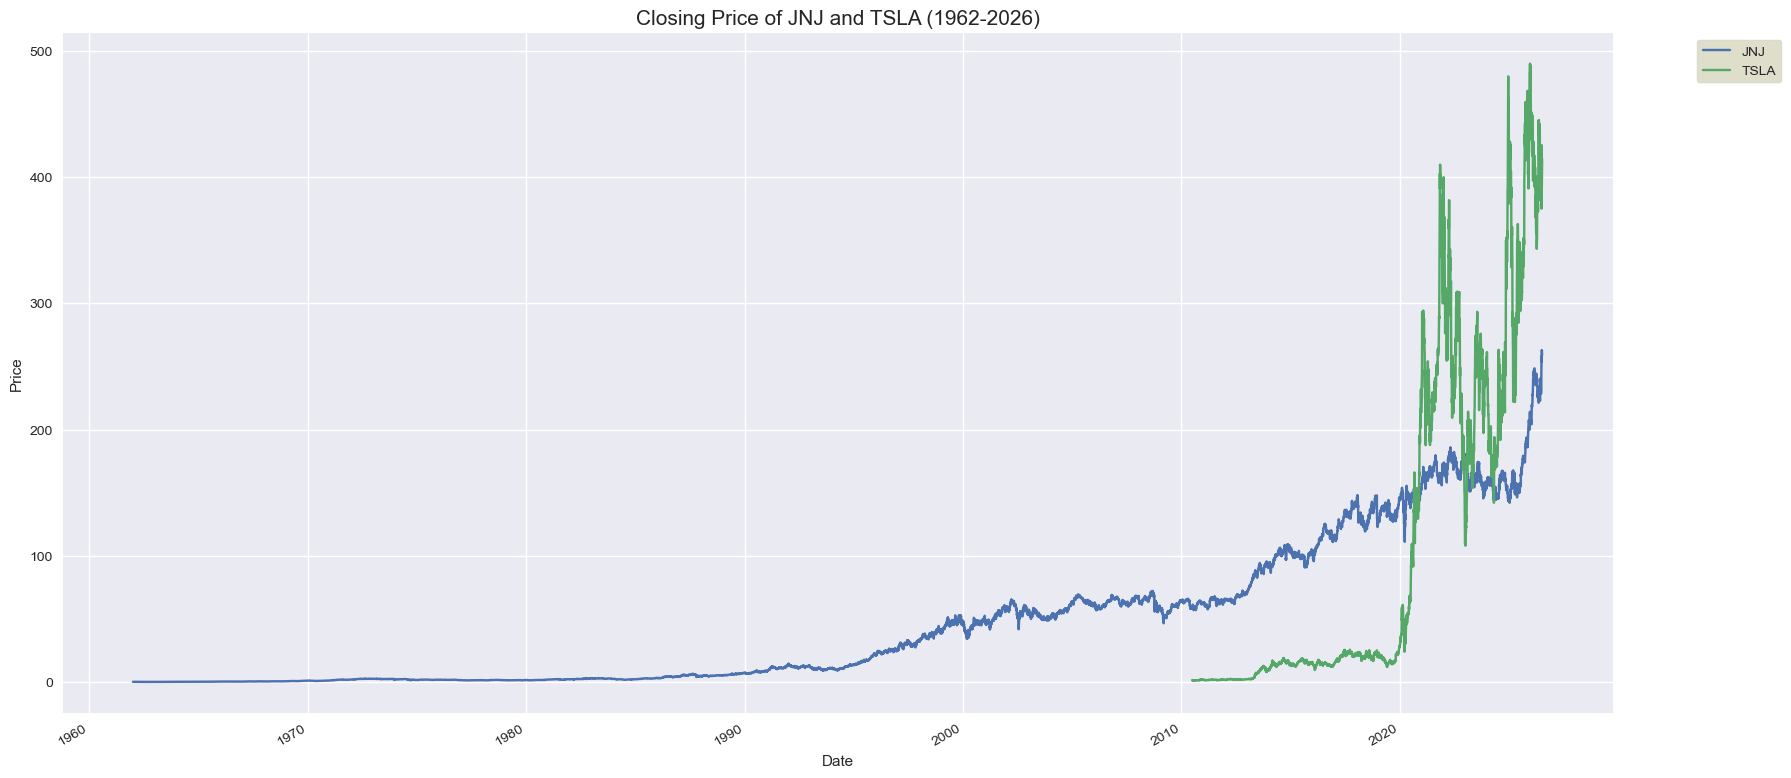

In [211]:
df.Close.plot(figsize = (20,10))
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left" , frameon = True , facecolor = "#d7d6bf", fancybox = True)

plt.title("Closing Price of JNJ and TSLA (1962-2026)", fontsize = 15)
plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

In [212]:
df

Price      Adj Close             Close          Dividends            High  \
Ticker           JNJ     TSLA      JNJ     TSLA       JNJ   TSLA      JNJ   
Date                                                                        
1962-01-02    0.0600      NaN   0.2234      NaN    0.0000    NaN   0.2234   
1962-01-03    0.0591      NaN   0.2199      NaN    0.0000    NaN   0.2211   
1962-01-04    0.0584      NaN   0.2176      NaN    0.0000    NaN   0.2211   
1962-01-05    0.0575      NaN   0.2141      NaN    0.0000    NaN   0.2159   
1962-01-08    0.0566      NaN   0.2106      NaN    0.0000    NaN   0.2124   
...              ...      ...      ...      ...       ...    ...      ...   
2026-06-29  258.5100 411.8400 258.5100 411.8400    0.0000 0.0000 258.5800   
2026-06-30  253.9700 420.6000 253.9700 420.6000    0.0000 0.0000 259.9000   
2026-07-01  253.9800 425.3000 253.9800 425.3000    0.0000 0.0000 254.2000   
2026-07-02  263.0400 393.4500 263.0400 393.4500    0.0000 0.0000 263.1000   
2026-07-06  259.0100 414.5100 259.0100 414.5100    0.0000 0.0000 261.3800   

Price                    Low              Open          Stock Splits         \
Ticker         TSLA      JNJ     TSLA      JNJ     TSLA          JNJ   TSLA   
Date                                                                          
1962-01-02      NaN   0.2222      NaN   0.2222      NaN       0.0000    NaN   
1962-01-03      NaN   0.2199      NaN   0.2211      NaN       0.0000    NaN   
1962-01-04      NaN   0.2176      NaN   0.2199      NaN       0.0000    NaN   
1962-01-05      NaN   0.2141      NaN   0.2159      NaN       0.0000    NaN   
1962-01-08      NaN   0.2106      NaN   0.2124      NaN       0.0000    NaN   
...             ...      ...      ...      ...      ...          ...    ...   
2026-06-29 413.2700 252.0300 379.3000 253.1900 381.7900       0.0000 0.0000   
2026-06-30 424.5400 253.1700 406.0000 259.0000 406.0000       0.0000 0.0000   
2026-07-01 432.8600 251.0800 418.0900 253.2500 421.4600       0.0000 0.0000   
2026-07-02 432.3500 254.0000 389.3000 255.7800 428.0100       0.0000 0.0000   
2026-07-06 419.5500 255.9300 390.5000 260.2250 397.3200       0.0000 0.0000   

Price        Volume                
Ticker          JNJ          TSLA  
Date                               
1962-01-02        0           NaN  
1962-01-03   345600           NaN  
1962-01-04   216000           NaN  
1962-01-05   129600           NaN  
1962-01-08   172800           NaN  
...             ...           ...  
2026-06-29  8608400 57645800.0000  
2026-06-30  8469500 43385600.0000  
2026-07-01  6516500 40127900.0000  
2026-07-02  7998700 73717700.0000  
2026-07-06  3083657 34312181.0000  

[16234 rows x 16 columns]

In [213]:
df.swaplevel(axis = "columns")

Ticker,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA,JNJ,TSLA
Price,Adj Close,Adj Close,Close,Close,Dividends,Dividends,High,High,Low,Low,Open,Open,Stock Splits,Stock Splits,Volume,Volume
Date,,,,,,,,,,,,,,,,
1962-01-02,0.0600,NaN,0.2234,NaN,0.0000,NaN,0.2234,NaN,0.2222,NaN,0.2222,NaN,0.0000,NaN,0,NaN
1962-01-03,0.0591,NaN,0.2199,NaN,0.0000,NaN,0.2211,NaN,0.2199,NaN,0.2211,NaN,0.0000,NaN,345600,NaN
1962-01-04,0.0584,NaN,0.2176,NaN,0.0000,NaN,0.2211,NaN,0.2176,NaN,0.2199,NaN,0.0000,NaN,216000,NaN
1962-01-05,0.0575,NaN,0.2141,NaN,0.0000,NaN,0.2159,NaN,0.2141,NaN,0.2159,NaN,0.0000,NaN,129600,NaN
1962-01-08,0.0566,NaN,0.2106,NaN,0.0000,NaN,0.2124,NaN,0.2106,NaN,0.2124,NaN,0.0000,NaN,172800,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,258.5100,411.8400,258.5100,411.8400,0.0000,0.0000,258.5800,413.2700,252.0300,379.3000,253.1900,381.7900,0.0000,0.0000,8608400,57645800.0000
2026-06-30,253.9700,420.6000,253.9700,420.6000,0.0000,0.0000,259.9000,424.5400,253.1700,406.0000,259.0000,406.0000,0.0000,0.0000,8469500,43385600.0000


In [214]:
df.swaplevel(axis = "columns").sort_index(axis = "columns")


Ticker           JNJ                                                \
Price      Adj Close    Close Dividends     High      Low     Open   
Date                                                                 
1962-01-02    0.0600   0.2234    0.0000   0.2234   0.2222   0.2222   
1962-01-03    0.0591   0.2199    0.0000   0.2211   0.2199   0.2211   
1962-01-04    0.0584   0.2176    0.0000   0.2211   0.2176   0.2199   
1962-01-05    0.0575   0.2141    0.0000   0.2159   0.2141   0.2159   
1962-01-08    0.0566   0.2106    0.0000   0.2124   0.2106   0.2124   
...              ...      ...       ...      ...      ...      ...   
2026-06-29  258.5100 258.5100    0.0000 258.5800 252.0300 253.1900   
2026-06-30  253.9700 253.9700    0.0000 259.9000 253.1700 259.0000   
2026-07-01  253.9800 253.9800    0.0000 254.2000 251.0800 253.2500   
2026-07-02  263.0400 263.0400    0.0000 263.1000 254.0000 255.7800   
2026-07-06  259.0100 259.0100    0.0000 261.3800 255.9300 260.2250   

Ticker                                TSLA                              \
Price      Stock Splits   Volume Adj Close    Close Dividends     High   
Date                                                                     
1962-01-02       0.0000        0       NaN      NaN       NaN      NaN   
1962-01-03       0.0000   345600       NaN      NaN       NaN      NaN   
1962-01-04       0.0000   216000       NaN      NaN       NaN      NaN   
1962-01-05       0.0000   129600       NaN      NaN       NaN      NaN   
1962-01-08       0.0000   172800       NaN      NaN       NaN      NaN   
...                 ...      ...       ...      ...       ...      ...   
2026-06-29       0.0000  8608400  411.8400 411.8400    0.0000 413.2700   
2026-06-30       0.0000  8469500  420.6000 420.6000    0.0000 424.5400   
2026-07-01       0.0000  6516500  425.3000 425.3000    0.0000 432.8600   
2026-07-02       0.0000  7998700  393.4500 393.4500    0.0000 432.3500   
2026-07-06       0.0000  3083657  414.5100 414.5100    0.0000 419.5500   

Ticker                                                   
Price           Low     Open Stock Splits        Volume  
Date                                                     
1962-01-02      NaN      NaN          NaN           NaN  
1962-01-03      NaN      NaN          NaN           NaN  
1962-01-04      NaN      NaN          NaN           NaN  
1962-01-05      NaN      NaN          NaN           NaN  
1962-01-08      NaN      NaN          NaN           NaN  
...             ...      ...          ...           ...  
2026-06-29 379.3000 381.7900       0.0000 57645800.0000  
2026-06-30 406.0000 406.0000       0.0000 43385600.0000  
2026-07-01 418.0900 421.4600       0.0000 40127900.0000  
2026-07-02 389.3000 428.0100       0.0000 73717700.0000  
2026-07-06 390.5000 397.3200       0.0000 34312181.0000  

[16234 rows x 16 columns]

In [215]:
df = df.swaplevel(axis = "columns").sort_index(axis = "columns")
df

Ticker           JNJ                                                \
Price      Adj Close    Close Dividends     High      Low     Open   
Date                                                                 
1962-01-02    0.0600   0.2234    0.0000   0.2234   0.2222   0.2222   
1962-01-03    0.0591   0.2199    0.0000   0.2211   0.2199   0.2211   
1962-01-04    0.0584   0.2176    0.0000   0.2211   0.2176   0.2199   
1962-01-05    0.0575   0.2141    0.0000   0.2159   0.2141   0.2159   
1962-01-08    0.0566   0.2106    0.0000   0.2124   0.2106   0.2124   
...              ...      ...       ...      ...      ...      ...   
2026-06-29  258.5100 258.5100    0.0000 258.5800 252.0300 253.1900   
2026-06-30  253.9700 253.9700    0.0000 259.9000 253.1700 259.0000   
2026-07-01  253.9800 253.9800    0.0000 254.2000 251.0800 253.2500   
2026-07-02  263.0400 263.0400    0.0000 263.1000 254.0000 255.7800   
2026-07-06  259.0100 259.0100    0.0000 261.3800 255.9300 260.2250   

Ticker                                TSLA                              \
Price      Stock Splits   Volume Adj Close    Close Dividends     High   
Date                                                                     
1962-01-02       0.0000        0       NaN      NaN       NaN      NaN   
1962-01-03       0.0000   345600       NaN      NaN       NaN      NaN   
1962-01-04       0.0000   216000       NaN      NaN       NaN      NaN   
1962-01-05       0.0000   129600       NaN      NaN       NaN      NaN   
1962-01-08       0.0000   172800       NaN      NaN       NaN      NaN   
...                 ...      ...       ...      ...       ...      ...   
2026-06-29       0.0000  8608400  411.8400 411.8400    0.0000 413.2700   
2026-06-30       0.0000  8469500  420.6000 420.6000    0.0000 424.5400   
2026-07-01       0.0000  6516500  425.3000 425.3000    0.0000 432.8600   
2026-07-02       0.0000  7998700  393.4500 393.4500    0.0000 432.3500   
2026-07-06       0.0000  3083657  414.5100 414.5100    0.0000 419.5500   

Ticker                                                   
Price           Low     Open Stock Splits        Volume  
Date                                                     
1962-01-02      NaN      NaN          NaN           NaN  
1962-01-03      NaN      NaN          NaN           NaN  
1962-01-04      NaN      NaN          NaN           NaN  
1962-01-05      NaN      NaN          NaN           NaN  
1962-01-08      NaN      NaN          NaN           NaN  
...             ...      ...          ...           ...  
2026-06-29 379.3000 381.7900       0.0000 57645800.0000  
2026-06-30 406.0000 406.0000       0.0000 43385600.0000  
2026-07-01 418.0900 421.4600       0.0000 40127900.0000  
2026-07-02 389.3000 428.0100       0.0000 73717700.0000  
2026-07-06 390.5000 397.3200       0.0000 34312181.0000  

[16234 rows x 16 columns]

In [216]:
df.columns.to_flat_index()

Index([    ('JNJ', 'Adj Close'),         ('JNJ', 'Close'),
           ('JNJ', 'Dividends'),          ('JNJ', 'High'),
                 ('JNJ', 'Low'),          ('JNJ', 'Open'),
        ('JNJ', 'Stock Splits'),        ('JNJ', 'Volume'),
          ('TSLA', 'Adj Close'),        ('TSLA', 'Close'),
          ('TSLA', 'Dividends'),         ('TSLA', 'High'),
                ('TSLA', 'Low'),         ('TSLA', 'Open'),
       ('TSLA', 'Stock Splits'),       ('TSLA', 'Volume')],
      dtype='object')

In [217]:
pd.MultiIndex.from_tuples(df.columns.to_flat_index())

MultiIndex([( 'JNJ',    'Adj Close'),
            ( 'JNJ',        'Close'),
            ( 'JNJ',    'Dividends'),
            ( 'JNJ',         'High'),
            ( 'JNJ',          'Low'),
            ( 'JNJ',         'Open'),
            ( 'JNJ', 'Stock Splits'),
            ( 'JNJ',       'Volume'),
            ('TSLA',    'Adj Close'),
            ('TSLA',        'Close'),
            ('TSLA',    'Dividends'),
            ('TSLA',         'High'),
            ('TSLA',          'Low'),
            ('TSLA',         'Open'),
            ('TSLA', 'Stock Splits'),
            ('TSLA',       'Volume')],
           )

In [218]:
df.columns

MultiIndex([( 'JNJ',    'Adj Close'),
            ( 'JNJ',        'Close'),
            ( 'JNJ',    'Dividends'),
            ( 'JNJ',         'High'),
            ( 'JNJ',          'Low'),
            ( 'JNJ',         'Open'),
            ( 'JNJ', 'Stock Splits'),
            ( 'JNJ',       'Volume'),
            ('TSLA',    'Adj Close'),
            ('TSLA',        'Close'),
            ('TSLA',    'Dividends'),
            ('TSLA',         'High'),
            ('TSLA',          'Low'),
            ('TSLA',         'Open'),
            ('TSLA', 'Stock Splits'),
            ('TSLA',       'Volume')],
           names=['Ticker', 'Price'])

2. Analyze and compare Dividends, Stock Price Increase and Dividend Policy

In [219]:
jnj = df.JNJ
jnj

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
1962-01-02,0.0600,0.2234,0.0000,0.2234,0.2222,0.2222,0.0000,0
1962-01-03,0.0591,0.2199,0.0000,0.2211,0.2199,0.2211,0.0000,345600
1962-01-04,0.0584,0.2176,0.0000,0.2211,0.2176,0.2199,0.0000,216000
1962-01-05,0.0575,0.2141,0.0000,0.2159,0.2141,0.2159,0.0000,129600
1962-01-08,0.0566,0.2106,0.0000,0.2124,0.2106,0.2124,0.0000,172800
...,...,...,...,...,...,...,...,...
2026-06-29,258.5100,258.5100,0.0000,258.5800,252.0300,253.1900,0.0000,8608400
2026-06-30,253.9700,253.9700,0.0000,259.9000,253.1700,259.0000,0.0000,8469500
2026-07-01,253.9800,253.9800,0.0000,254.2000,251.0800,253.2500,0.0000,6516500


Price Increase for JNJ

In [ ]:
jnj.Close.iloc[-1] - jnj.Close.iloc[0]

np.float64(258.7866297662258)

In [222]:
jnj.Dividends.value_counts(dropna = False, ascending = False)

Dividends
0.0000    15976
0.0006       10
0.0021        7
0.0014        6
0.0010        6
          ...  
0.0036        1
0.0027        1
0.0031        1
0.0063        1
1.3400        1
Name: count, Length: 68, dtype: int64

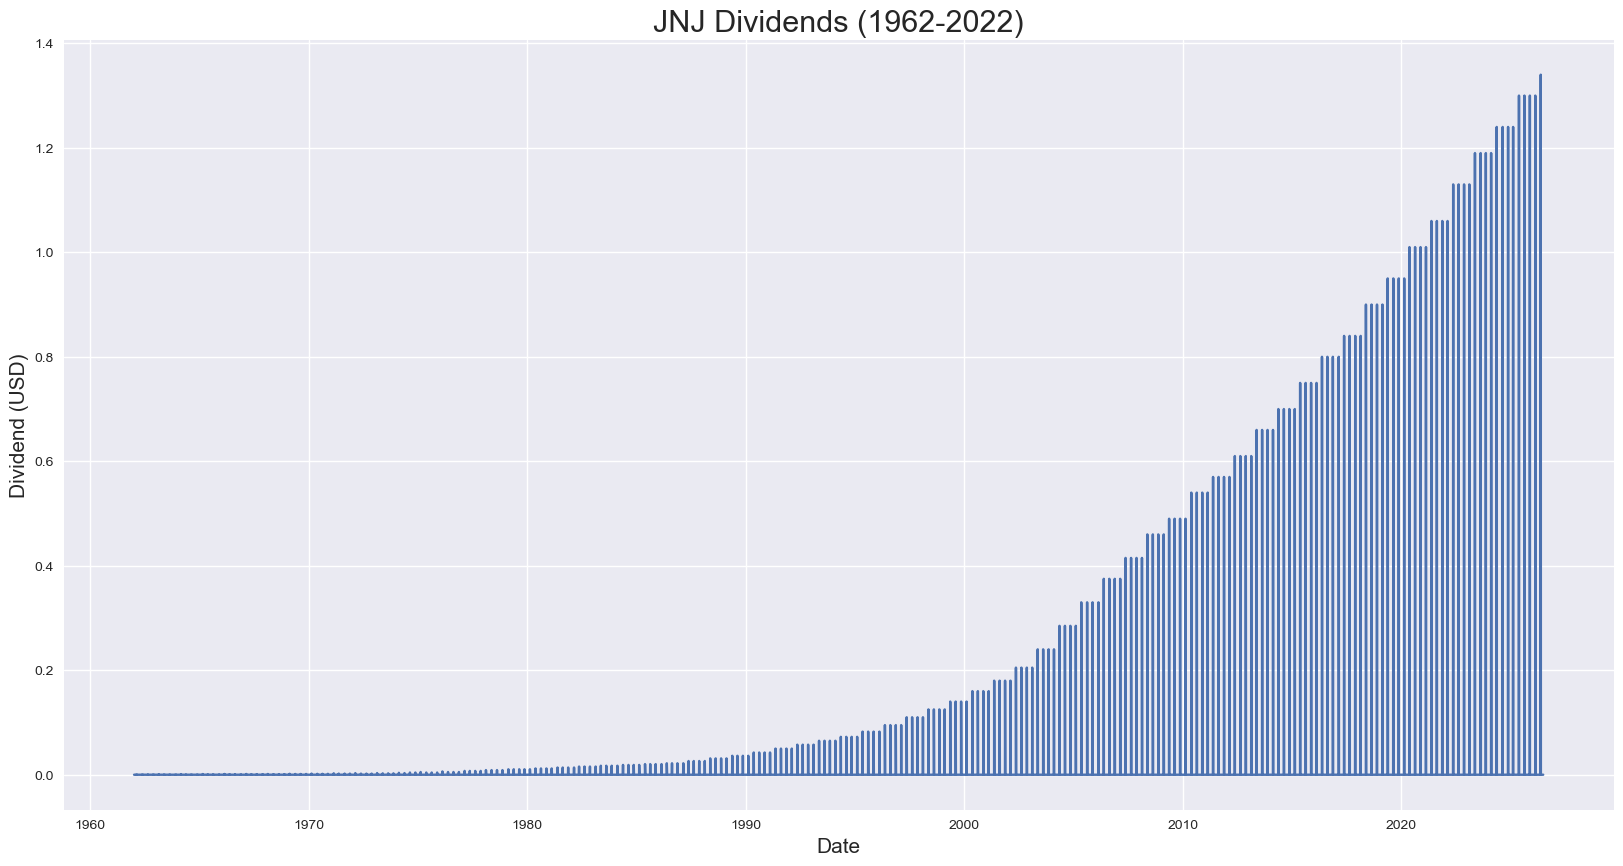

In [207]:
plt.figure(figsize = (20,10))
plt.plot(jnj.Dividends)
plt.title("JNJ Dividends (1962-2022)", fontsize = 22)
plt.ylabel("Dividend (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

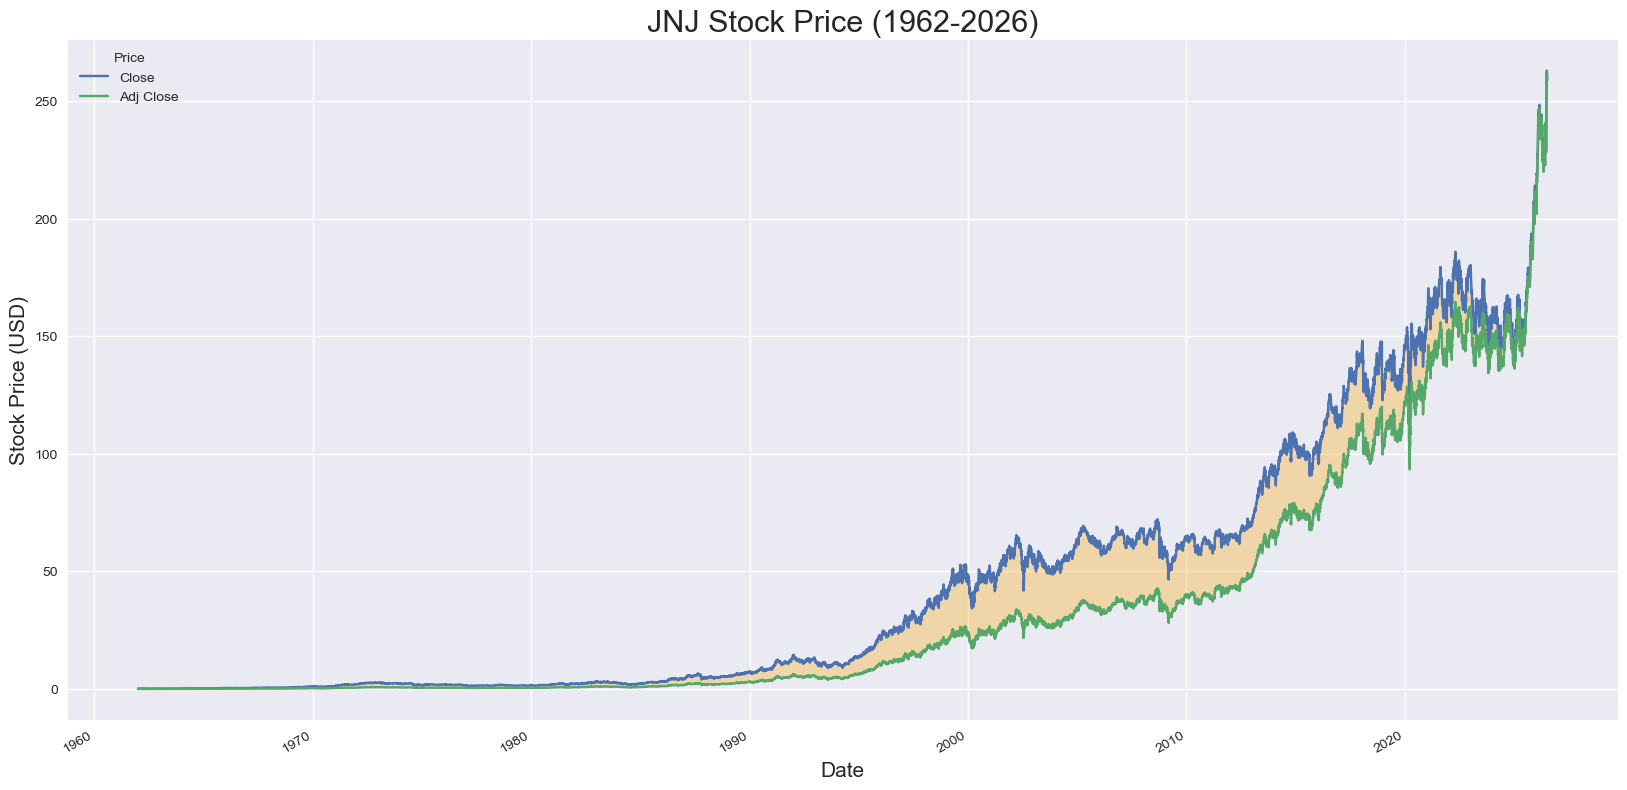

In [261]:
jnj.loc[:,["Close" ,"Adj Close"]].plot(figsize = (20,10))
plt.fill_between(x = jnj.index , y1 = jnj.Close , y2 = jnj["Adj Close"] , alpha = 0.3 , color = "orange")
plt.title("JNJ Stock Price (1962-2026)", fontsize = 22)
plt.ylabel("Stock Price (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

In [263]:
mask_2026 =  jnj.index[jnj.index.year.isin([2026])]
mask_2026

DatetimeIndex(['2026-01-02', '2026-01-05', '2026-01-06', '2026-01-07',
               '2026-01-08', '2026-01-09', '2026-01-12', '2026-01-13',
               '2026-01-14', '2026-01-15',
               ...
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-06'],
              dtype='datetime64[ns]', name='Date', length=126, freq=None)

In [273]:
jnj.Close[mask_2026]

Date
2026-01-02   207.3500
2026-01-05   204.3100
2026-01-06   204.7900
2026-01-07   207.4900
2026-01-08   205.7500
               ...   
2026-06-29   258.5100
2026-06-30   253.9700
2026-07-01   253.9800
2026-07-02   263.0400
2026-07-06   259.0100
Name: Close, Length: 126, dtype: float64

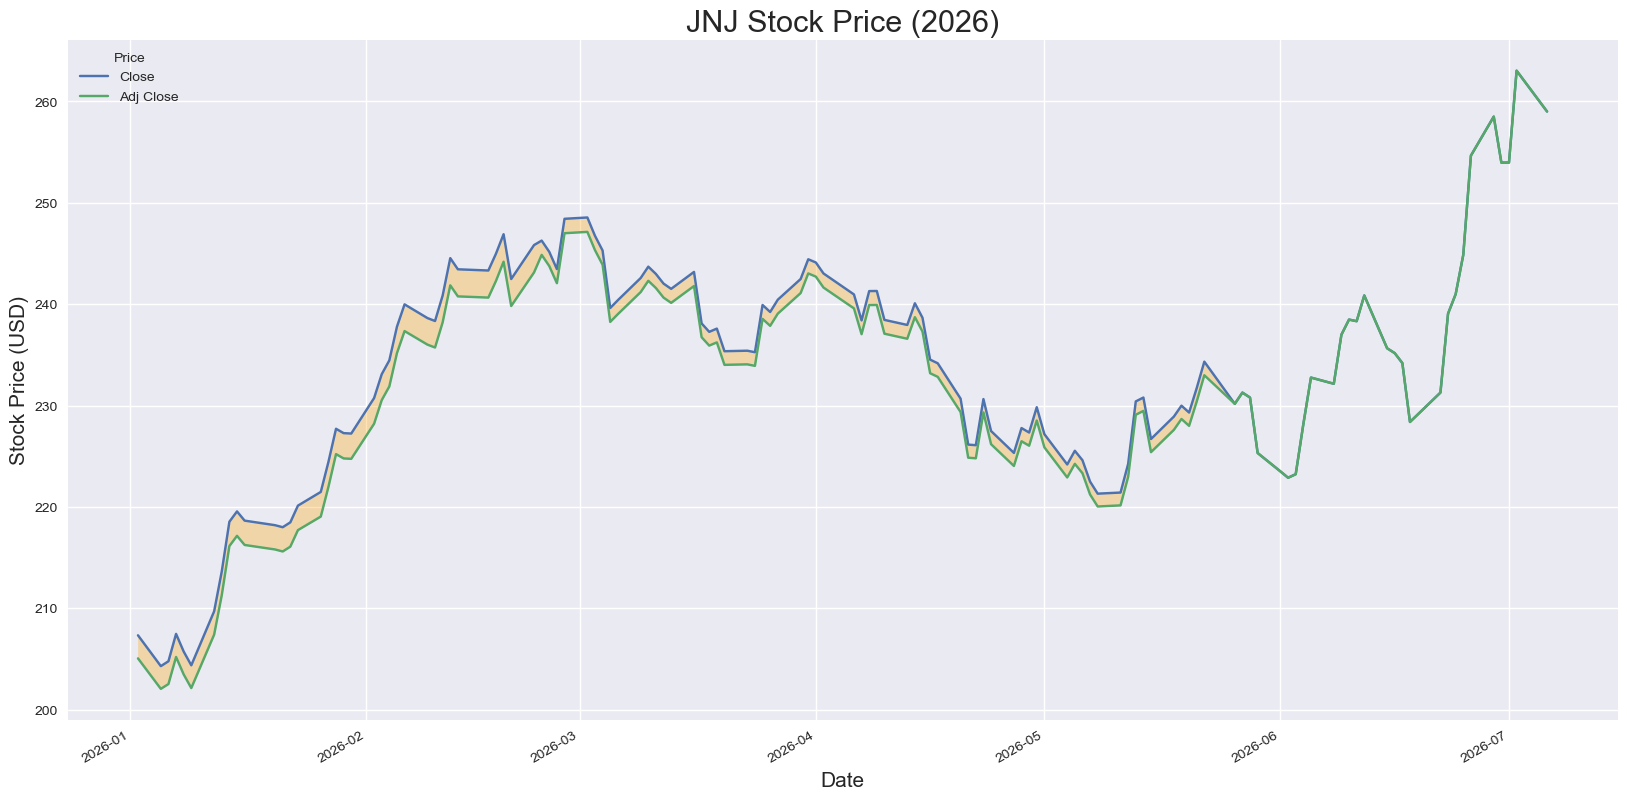

In [288]:
jnj.loc["2026",["Close" ,"Adj Close" ]].plot(figsize = (20,10))
plt.fill_between(x = mask_2026 , y1 = jnj.Close.loc[mask_2026] , y2 = jnj["Adj Close"].loc[mask_2026] , alpha = 0.3 , color = "orange")
plt.title("JNJ Stock Price (2026)", fontsize = 22)
plt.ylabel("Stock Price (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

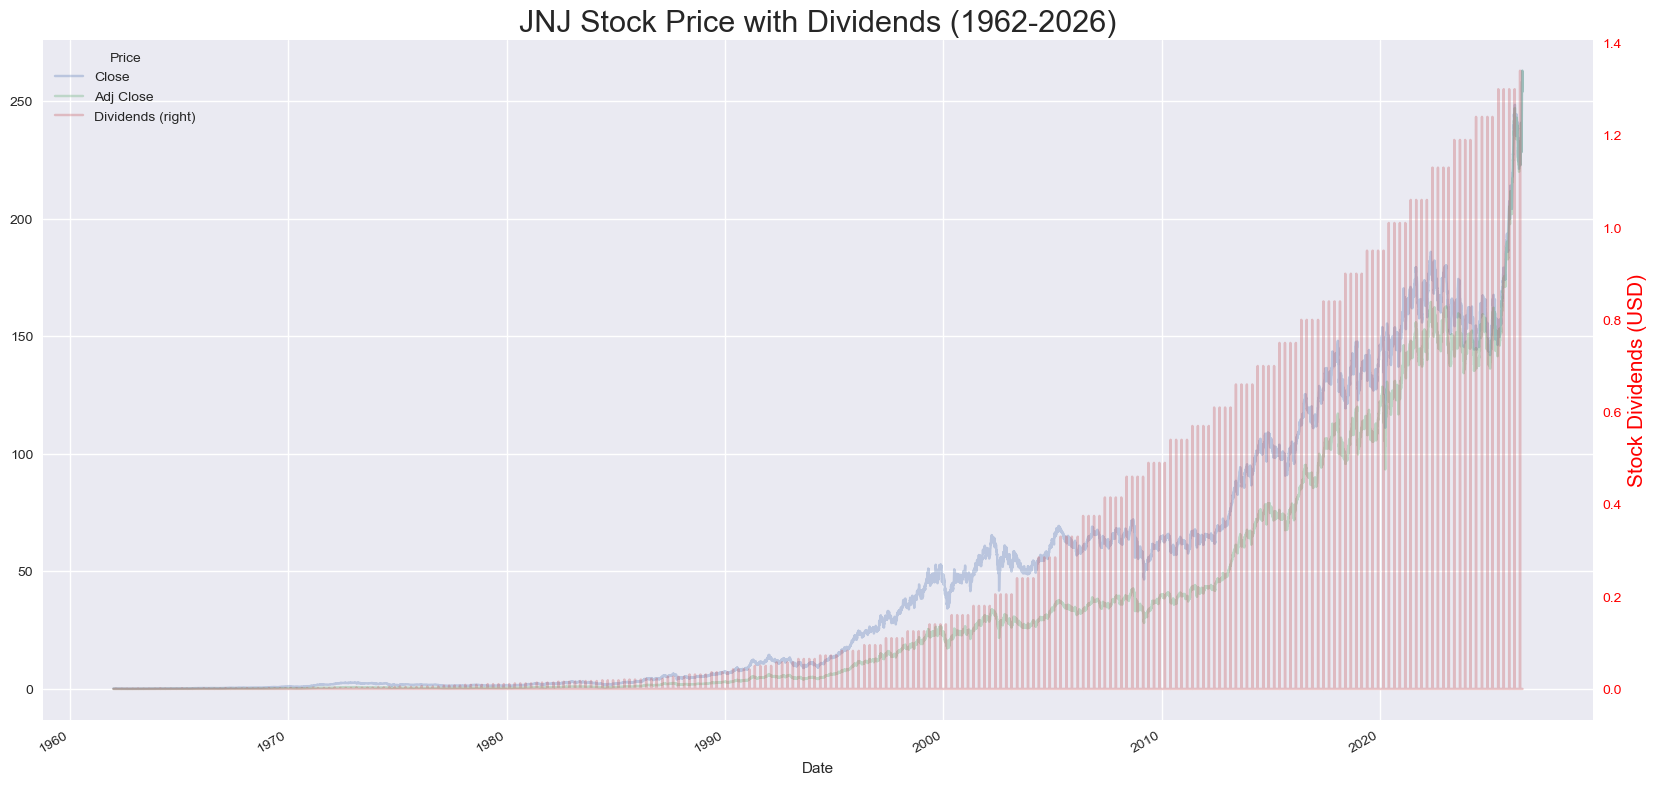

In [237]:
jnj.loc[:,["Close" ,"Adj Close" ,"Dividends"]].plot(figsize = (20,10) , secondary_y = "Dividends" , alpha = 0.3)
plt.title("JNJ Stock Price with Dividends (1962-2026)", fontsize = 22)
plt.ylabel("Stock Dividends (USD)", fontsize = 15 ,color = "red")
plt.yticks(color = "red")
plt.xlabel("Date", fontsize = 15)
plt.show()

In [290]:
jnj.Dividends.sum()

np.float64(75.35008400000001)

In [292]:
jnj.Close.iloc[-1] - jnj.Close.iloc[0]

np.float64(258.7866297662258)

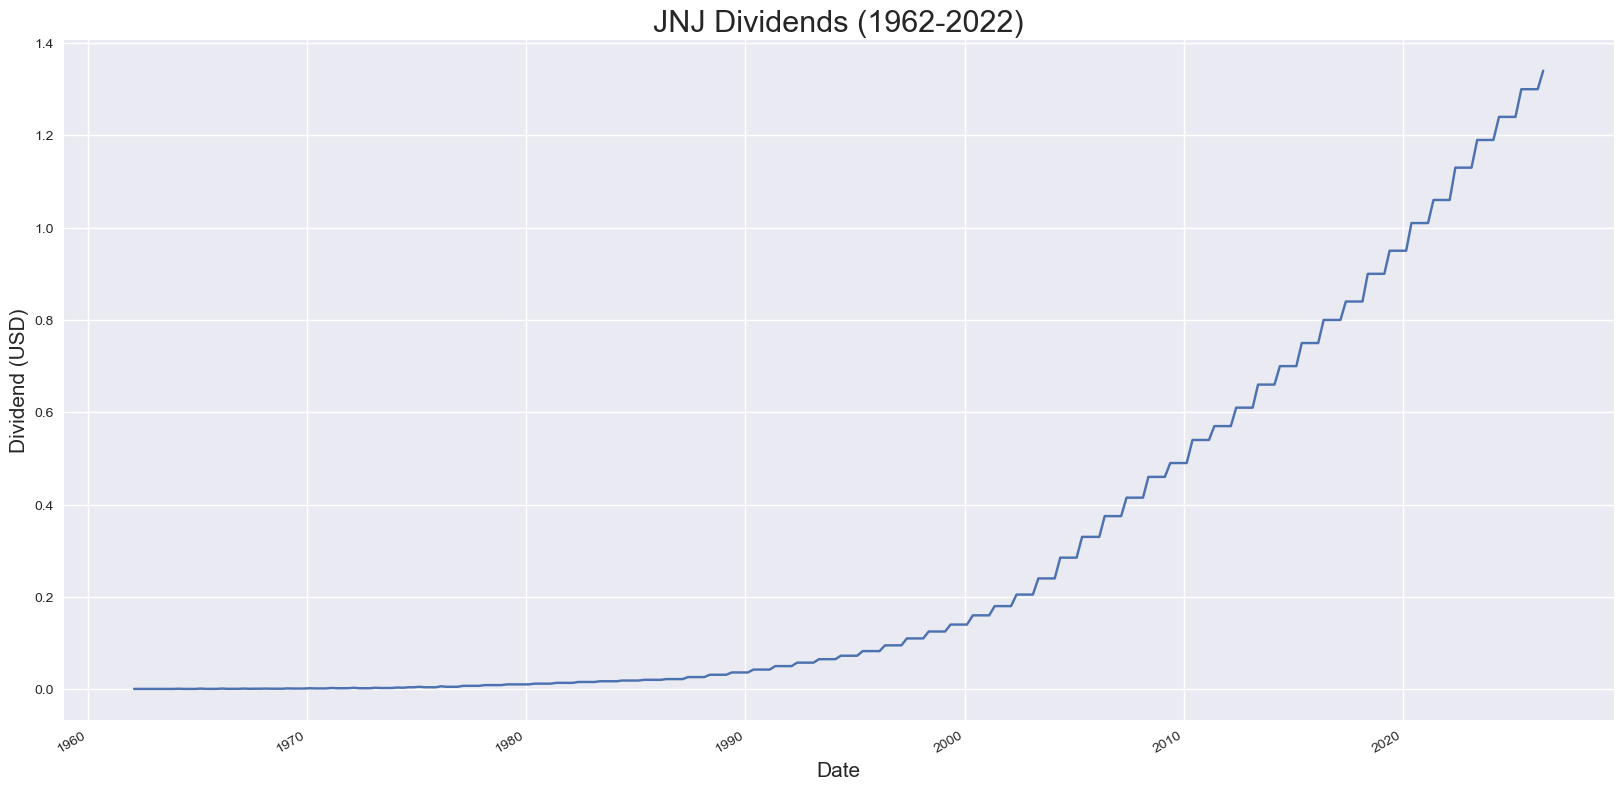

In [294]:
jnj.Dividends[jnj.Dividends != 0].plot(figsize = (20,10))
plt.title("JNJ Dividends (1962-2022)", fontsize = 22)
plt.ylabel("Dividend (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

We can conclude that a significant part of the totlal return in dividends.

### TSLA:

In [277]:
tsla = df.TSLA
tsla

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
1962-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-06-29,411.8400,411.8400,0.0000,413.2700,379.3000,381.7900,0.0000,57645800.0000
2026-06-30,420.6000,420.6000,0.0000,424.5400,406.0000,406.0000,0.0000,43385600.0000
2026-07-01,425.3000,425.3000,0.0000,432.8600,418.0900,421.4600,0.0000,40127900.0000


In [278]:
tsla.Dividends.value_counts(dropna = False)

Dividends
NaN       12206
0.0000     4028
Name: count, dtype: int64

In [279]:
tsla.Dividends.sum()

np.float64(0.0)

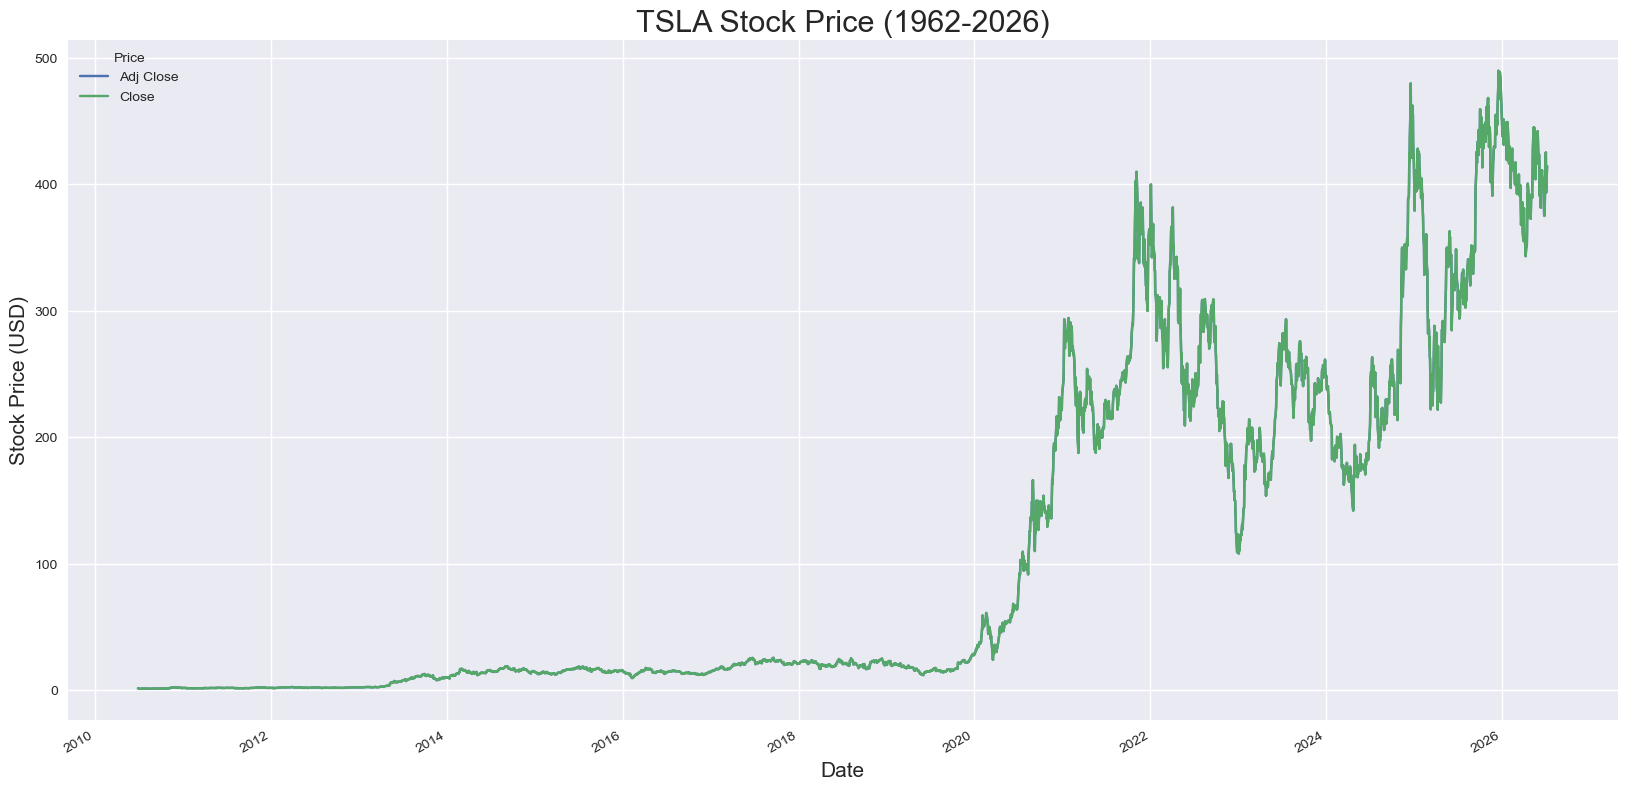

In [280]:
tsla.loc[: , ["Adj Close", "Close"]].plot(figsize = (20,10))
plt.title("TSLA Stock Price (1962-2026)", fontsize = 22)
plt.ylabel("Stock Price (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

In [282]:
tsla.Close.dropna().iloc[-1] - tsla.Close.dropna().iloc[0]

np.float64(412.91734278202057)

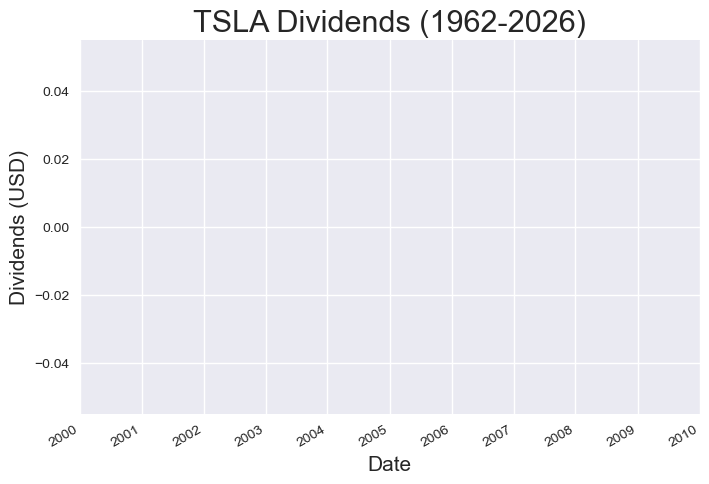

In [289]:
tsla.loc[tsla.Dividends != 0].Dividends.plot()
plt.title("TSLA Dividends (1962-2026)", fontsize = 22)
plt.ylabel("Dividends (USD)", fontsize = 15)
plt.xlabel("Date", fontsize = 15)
plt.show()

3. Which stock is the high-dividend stock?

JNJ

__-> JNJ is the high-dividend stock__